# Assignment 1 of Natural Language Processing
## Spam, Ham, and Phishing Email Classification using Machine Learning Techniques

Work assembled by Alejandro Gonçalves (202205564), Francisca Mihalache (202206022) and João Sousa (202205238).


## Table of Contents

1. [Introduction](#1-introduction)
2. [Dataset Description](#2-dataset-description)
   - 2.1. [Data Provenance](#21-data-provenance)
   - 2.2. [Data Structure](#21-data-structure)
   - 2.3. [Class Labels](#22-class-labels)
   - 2.4. [Dataset Size](#23-dataset-size)
   - 2.5. [Dataset Characteristics and Challenges](#24-dataset-characteristics-and-challenges)

3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
   - 3.1. [Data Loading and Initial Inspection](#31-data-loading-and-initial-inspection)
   - 3.2. [Class Distribution Analysis](#32-class-distribution-analysis)
   - 3.3. [Text Length and Complexity Analysis](#33-text-length-and-complexity-analysis)
   - 3.4. [Linguistic Content Analysis (N-grams)](#34-linguistic-content-analysis-n-grams)
   - 3.5. [Special Character & Punctuation Density](#35-special-character--punctuation-density)
   - 3.6. [Vocabulary Richness (Lexical Diversity)]()

4. [Text Preprocessing](#4-text-preprocessing)
   - 4.1. [Data Loading and Initial Cleaning](#41-data-loading-and-initial-cleaning)
   - 4.2. [Lowercasing and Punctuation Removal](#42-lowercasing-and-punctuation-removal)
   - 4.3. [Tokenization and Stopword Removal](#43-tokenization-and-stopword-removal)
   - 4.4. [Lemmatization](#44-lemmatization)

5. [Feature Representation](#5-feature-representation)
   - 5.1. [TF-IDF (Term Frequency-Inverse Document Frequency)](#51-tf-idf-term-frequency-inverse-document-frequency)
   - 5.2. [Word2Vec](#52-word2vec)

6. [Baseline Model & Data Splitting](#6-baseline-model--data-splitting)
   - 6.1. [Train-Test Split](#61-train-test-split)
   - 6.2. [Why a Baseline Model?](#62-why-a-baseline-model)

7. [Classification Models](#7-classification-models)
   - 7.1. [Logistic Regression (Standard)](#71-logistic-regression-standard)
   - 7.2. [Random Forest (Standard)](#72-random-forest-standard)
   - 7.3. [Support Vector Machine (Standard)](#73-support-vector-machine-standard)
   - 7.4. [Multi-Layer Percepton (Standard)](#74-multi-layer-percepton-standard)
   - 7.5. [Comparison of Standard Models](#74-comparison-of-standard-models)

8. [Addressing Class Imbalance: Cost-Sensitive Learning via Class Weights](#8-addressing-class-imbalance-cost-sensitive-learning-via-class-weights)
   - 8.1. [Logistic Regression (with Weights)](#81-logistic-regression-with-weights)
   - 8.2. [Multi-Layer Percepton (with Weights)](#82-multi-layer-percepton-with-weights)
   - 8.3. [Comparison: Standard vs. Cost-Sensitive Models](#83-comparison-standard-vs-cost-sensitive-models)

9. [Error Analysis: Investigating Model Blind Spots](#9-error-analysis-investigating-model-blind-spots)
   - 9.1. [Qualitative Analysis of Critical Evasion Techniques](#91-qualitative-analysis-of-critical-evasion-techniques)

10. [Discussion and Related Work](#10-discussion-and-related-work)

11. [Conclusion](#11-conclusion)

12. [References](#12-references)

### 1. Introduction
[[go back to the top]](#table-of-contents)

Text classification remains a fundamental task in Natural Language Processing (NLP), as it enables computers to automatically understand and organize large amounts of textual data. It plays a key role in security-related applications, such as detecting fraudulent messages, identifying phishing attempts, and filtering unwanted or harmful communications.

This project focuses on classifying emails into three categories: **Ham**, **Spam**, and **Phishing**. As phishing attacks become more sophisticated and increasingly resemble legitimate messages, it is essential to develop reliable traditional machine learning classifiers that can detect them efficiently. Such approaches are particularly valuable because they offer fast predictions and can be deployed in real-world systems where low latency and reliability are critical.

The objective of this assignment is to design, implement, and evaluate a complete NLP pipeline using a large-scale dataset of approximately 300,000 emails. Unlike traditional spam detection, which usually focuses on a simple binary distinction, this task is more challenging because it requires separating phishing emails from regular spam and legitimate messages. Phishing emails are often carefully crafted to appear trustworthy, making them harder to detect. To address this challenge, we explore different feature representation techniques, including sparse methods such as TF-IDF and dense representations based on word embeddings. These features are then used with traditional machine learning classifiers, including Naive Bayes, Support Vector Machines (SVM), and Gradient Boosting (XGBoost), allowing us to evaluate their effectiveness in accurately identifying each email category.

This report documents the entire development process, including:

- **Exploratory Data Analysis (EDA):** Identifying class imbalances and linguistic patterns.

- **Pre-processing & Feature Engineering:** Justifying the selection of lexicons and dimensionality reduction.

- **Model Evaluation:** A systematic comparison of classifiers using Precision, Recall, and Macro-F1 metrics.

- **Error Analysis:** A qualitative assessment of misclassified instances to identify model limitations.

By comparing different feature representations and machine learning models, this project aims to better understand how traditional ML techniques perform when applied to large-scale, real-world security datasets. This analysis helps highlight the strengths and limitations of each approach, providing insight into which combinations of features and classifiers are most effective for detecting spam and phishing in modern communication systems.


### 2. Dataset Description
[[go back to the top]](#table-of-contents)


#### 2.1. Data Provenance
[[go back to the topic]](#2-dataset-description)

The dataset is an ensemble of several historical and benchmark NLP collections, including the Enron Corpus (for legitimate communication), SpamAssassin, and specialized phishing repositories like the Nazario Phishing Archive. This diversity ensures that the model is exposed to various email formats, from professional corporate exchanges to modern fraudulent templates.

#### 2.2. Dataset Structure
[[go back to the topic]](#2-dataset-description)

The dataset consists of two main columns:

- **text**: contains the raw email content. This includes the body of the message and may contain informal language, formatting artifacts, or domain-specific vocabulary.
- **label**: contains the numerical class assigned to each email, representing its category.

Each row corresponds to a single email instance and its associated label.

#### 2.3. Class Labels
[[go back to the topic]](#2-dataset-description)

The classification task is a multi-class problem with three categories:

- **0 — Ham**: legitimate, non-malicious emails  
- **1 — Phishing**: malicious emails designed to deceive users and steal sensitive information  
- **2 — Spam**: unsolicited or irrelevant commercial or bulk emails  

This distinction is particularly important because phishing emails often closely resemble legitimate communication, making them more difficult to detect than traditional spam.


#### 2.4. Dataset Size
[[go back to the topic]](#2-dataset-description)

The dataset contains:

- **Total samples:** 365448 emails  
- **Number of classes:** 3  
- **Task type:** Multi-class text classification  
- **Language:** English  

The large size of the dataset makes it suitable for training and evaluating robust machine learning models and enables meaningful comparisons between different feature representations and classifiers.


#### 2.5. Dataset Characteristics and Challenges
[[go back to the topic]](#2-dataset-description)

This dataset presents several challenges typical of real-world NLP classification problems:

- High vocabulary diversity  
- Class overlap between phishing and legitimate emails (Phishing emails are designed to mimic Ham, making simple keyword detection insufficient.) 
- Informal and inconsistent text formatting  
- Potential class imbalance  
- Scalability (With over 365000 samples, creating a sparse feature matrix (like TF-IDF) requires careful memory management and feature selection (e.g., limiting max_features) to remain computationally feasible on a standard machine without using Deep Learning.)

These characteristics make the dataset a realistic benchmark for evaluating traditional machine learning approaches to email security and automated text classification.

### 3. Exploratory Data Analysis (EDA)
[[go back to the top]](#table-of-contents)

Before diving into preprocessing and model training, it is crucial to understand the underlying structure and characteristics of our dataset. Exploratory Data Analysis (EDA) allows us to identify patterns, detect potential anomalies (such as empty messages), and quantify the distribution of our target classes.

In this section, we focus on three main aspects:

- **Class Distribution:** To determine if the dataset is balanced or if certain categories (like Phishing) are underrepresented.

- **Message Length Analysis:** To see if the number of words or characters differs significantly between legitimate emails and malicious ones.

- **Data Integrity:** Identifying missing values or duplicates that could bias the model's performance.

Understanding these factors is essential for choosing the right evaluation metrics (e.g., Accuracy vs. Macro-F1) and for justifying our preprocessing decisions.

#### Imports

In [1]:
import matplotlib.pyplot as plt
import string
import seaborn as sns
import numpy as np
import os
import joblib
import random
import copy
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from tqdm import tqdm
import re
import nltk
import optuna
import scipy.sparse as sp
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from gensim.models import Word2Vec

c:\Users\aleja\OneDrive\Documentos\GitHub\Natural-Language-Processing\nlp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 3.1. Data Loading and Initial Inspection
[[go back to the topic]](#3-exploratory-data-analysis-eda)

In [2]:
# Load the dataset
df = pd.read_csv('data/df.csv')

# 1. Dataset Dimensions
rows, cols = df.shape
print(f"Dataset Shape: {rows} rows and {cols} columns")

# 2. Alignment Check: Does every row have a label?
# We check if the number of labels matches the number of rows
total_labels = df['label'].count()
print(f"Total number of labels: {total_labels}")

if rows == total_labels:
    print("Verification Successful: Every row has an associated label.")
else:
    print(f"Warning: Integrity issue! {rows - total_labels} rows are missing a label.")

# 3. Text-Label Integrity (Missing values)
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing)

# 4. Basic Inspection of the first rows
print("\nFirst few rows of the dataset:")
print(df.head())

# 5. Numerical distribution of labels
print("\nNumerical distribution of labels:")
print(df['label'].value_counts())

Dataset Shape: 365448 rows and 2 columns
Total number of labels: 365448
Verification Successful: Every row has an associated label.

Missing values per column:
label    0
text     2
dtype: int64

First few rows of the dataset:
   label                                               text
0      0  wrong bill grace i ' ll forward original messa...
1      0  i have continued the hilcorp old ocean deal da...
2      0  several related issues have resulted in an inc...
3      0  one year rate for this one will be escapenumbe...
4      0  attached is the weekly deal report for escapen...

Numerical distribution of labels:
label
0    168455
2    154148
1     42845
Name: count, dtype: int64


In [3]:
# Check a specific "multi-line" row to see how Pandas handles it
# Let's find a row that likely has many newlines
sample_multi_line = df[df['text'].str.contains('\n', na=False)].iloc[0]

print(f"Label: {sample_multi_line['label']}")
print("-" * 30)
print(f"Text content (as seen by Python):\n{sample_multi_line['text'][:500]}") 
# Python will show \n where the VS Code breaks the line

Label: 2
------------------------------
Text content (as seen by Python):
hello , welcome to pharmo attached nline sho longing p
- one of the leadi dehiscent ng oniine pharmaceutical shops
coruscation v
melinite g
a collaborator l
flaming ll
l prestige a
imparity rac homeless l
radiotrician is developer va
u anecdotic m
andmanyother .
- save over 50 medication %
- worldwide shl prosector pplng
- total co enclitic nfidentiaiity
- over 5 miiiion customers carefree in 130 countries
have a ni acclamation ce day !


In [4]:
# Technical validation of the row vs. line discrepancy
logical_rows = len(df)
valid_labels = df['label'].count()

print(f"Logical Observations (Pandas): {logical_rows}")
print(f"Valid Labels found: {valid_labels}")

# Proof of multi-line content: Check if rows contain newline characters
multi_line_rows = df['text'].str.contains('\n').sum()
print(f"Rows containing internal line breaks: {multi_line_rows}")

if logical_rows == valid_labels:
    print("STATUS: Data integrity verified. Every logical row is correctly mapped to a label.")

Logical Observations (Pandas): 365448
Valid Labels found: 365448
Rows containing internal line breaks: 57812
STATUS: Data integrity verified. Every logical row is correctly mapped to a label.


During the initial inspection of the dataset, a discrepancy was observed between the number of physical lines displayed in a standard text editor (approximately 1.7 million) and the number of logical observations reported by the Pandas library (365448).

This difference is expected in raw email datasets and can be explained by how email content is stored and parsed.

**Embedded Newlines**

Many emails contain internal newline characters (`\n`) within the message body. These line breaks preserve the original structure and formatting of the email, such as:

- Professional signatures  
- Forwarded message threads  
- Bullet points or lists  
- Paragraph separation  

As a result, a single email can appear spread across multiple lines in a text editor, even though it still represents just one complete message.

---

**CSV Quoting Mechanism**

When stored in CSV format, email bodies containing line breaks are enclosed in double quotes (`"`). This ensures that the entire email content is treated as a single field. Data processing libraries such as Pandas correctly interpret all content within quotation marks as one logical observation, regardless of how many physical lines it occupies in the file.

Therefore, while the file appears to contain more lines at the physical level, the logical structure remains intact.

---

**Verification of Dataset Consistency**

To verify the integrity of the dataset after loading, the following checks were performed:

- `df.shape` confirmed the total number of observations
- `df["label"].count()` confirmed that each observation has a corresponding label

These checks verified that the dataset contains exactly **365448 valid samples**, each consisting of:

- One email text (`text`)
- One corresponding class label (`label`)

This confirms that no data was lost, truncated, or misaligned during the loading and parsing process.

#### 3.2. Class Distribution Analysis
[[go back to the topic]](#3-exploratory-data-analysis-eda)

Class Distribution Percentage:
Label 0: 46.10%
Label 2: 42.18%
Label 1: 11.72%


C:\Users\João Sousa\AppData\Local\Temp\ipykernel_37644\1915763620.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


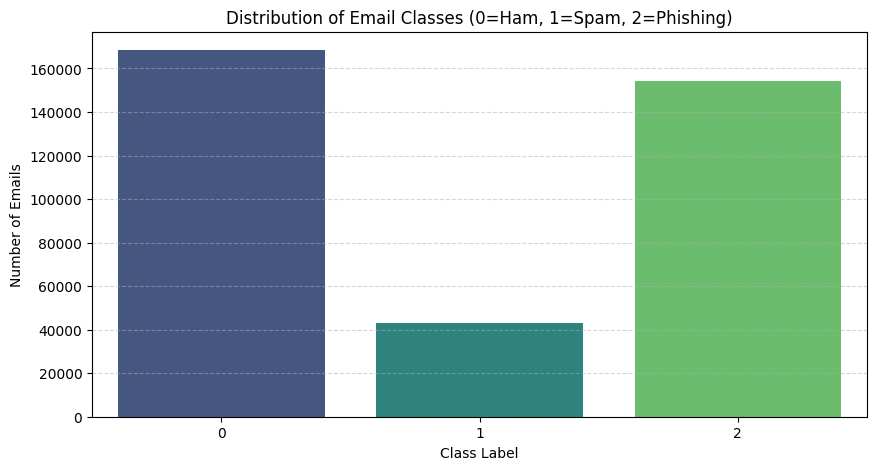

In [5]:
# Calculate percentages for the report
class_pct = df['label'].value_counts(normalize=True) * 100

print("Class Distribution Percentage:")
for label, pct in class_pct.items():
    print(f"Label {label}: {pct:.2f}%")

# Visualization: Bar Plot
plt.figure(figsize=(10, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Email Classes (0=Ham, 1=Spam, 2=Phishing)')
plt.xlabel('Class Label')
plt.ylabel('Number of Emails')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

                W3GQThe visualization of the class distribution reveals the internal balance of our dataset across the three target categories.

Key observations from the distribution:

- **Dominant Classes:** Both `Ham` and `Phishing` represent the majority of the dataset, with Ham being the most frequent class (exceeding 160000 samples) and `Phishing` following closely (approximately 150000 samples).

- **Minority Class:** The `Spam` category is significantly underrepresented compared to the others, with roughly 40000 samples.

- **Implications for Modeling:** This distribution indicates a class imbalance. While the model will have ample examples to learn the patterns of legitimate emails and phishing attempts, it may struggle with the specific characteristics of generic spam. Consequently, relying solely on Accuracy might be misleading. We must prioritize **Macro-F1 Score** to ensure the classifier performs consistently across all categories, especially the minority one.

#### 3.3. Text Length and Complexity Analysis
[[go back to the topic]](#3-exploratory-data-analysis-eda)

In this section, we analyze the linguistic volume of the emails. Understanding the distribution of word counts helps identify if specific classes, such as phishing, tend to be more concise or if certain spam campaigns are unusually wordy. This analysis is also vital for detecting outliers, extreme cases that could negatively impact the training of our traditional machine learning models.

Word Count Statistics per Class:
             mean          std  min  median        max
label                                                 
0      346.262367  4302.027953  0.0   161.0  1585483.0
1      121.350239   594.751582  0.0    55.0   107710.0
2      209.373161   334.387849  0.0   110.0    25393.0


C:\Users\João Sousa\AppData\Local\Temp\ipykernel_37644\3115556438.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='word_count', data=df, palette='Set2')


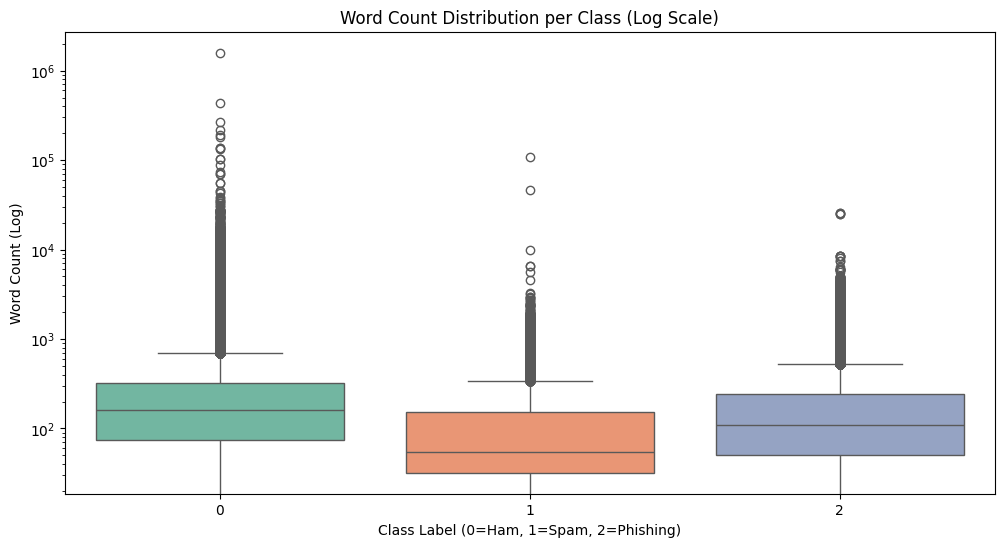

In [6]:
# Force conversion to string and handle potential NaN values explicitly
# We use .fillna('') to ensure no float objects are processed
df['text'] = df['text'].fillna('').astype(str)

# Calculate word count for each email
# Now we are 100% sure 'x' is a string
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Descriptive Statistics per Class
print("Word Count Statistics per Class:")
stats_report = df.groupby('label')['word_count'].describe()[['mean', 'std', 'min', '50%', 'max']]
stats_report = stats_report.rename(columns={'50%': 'median'})
print(stats_report)

# Visualization: Boxplot for Word Count (using Log Scale for readability)
plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='word_count', data=df, palette='Set2')
plt.yscale('log')
plt.title('Word Count Distribution per Class (Log Scale)')
plt.xlabel('Class Label (0=Ham, 1=Spam, 2=Phishing)')
plt.ylabel('Word Count (Log)')
plt.show()

The descriptive statistics reveal a significant "skewness" in the data, particularly in the Ham and Spam classes.

- **Ham (0) - Complexity and Massive Outliers:** This class exhibits the highest average (346 words) but a much lower median of 161 words. This gap indicates a right-skewed distribution, where most emails are around 160 words, but a few extreme outliers (reaching a maximum of 1585483 words) are pulling the mean upwards. Such extreme cases are likely system logs or corrupted files, not standard human communication.

- **Phishing (2) - Controlled Messaging:** Phishing attempts are more consistent, with a median of 110 words and a mean of 209. This suggests a deliberate strategy of being concise enough to induce quick action while maintaining enough professional "padding" to appear legitimate.

- **Spam (1) - Brief and Direct:** This is the most concise class, with a median of only 55 words. These messages typically rely on short promotional slogans or direct links rather than long-form text.

The presence of 2 missing values in the `text` column was handled by converting them into empty strings. Subsequent analysis showed that these, along with other pre-existing entries, resulted in a minimum word count of 0. These 'empty' observations are linguistically uninformative and will be removed in the preprocessing stage to prevent noise in the model training.

**The "Zero-Word" Issue:** All classes show a minimum value (`min`) of 0.0, indicating that some emails contain no usable textual content. These entries may correspond to empty messages or emails composed only of non-textual elements, such as images, attachments, or formatting artifacts. Since these observations contain no words, they do not provide any meaningful linguistic information for feature extraction or model training. Keeping them in the dataset could introduce noise and negatively affect model performance. Therefore, these entries must be identified and removed during the preprocessing stage.



#### 3.4. Linguistic Content Analysis (N-grams)
[[go back to the topic]](#3-exploratory-data-analysis-eda)

While word counts provide a structural overview, they do not reveal the semantic differences between classes. To understand the "vocabulary" of each category, we analyze the most frequent sequences of words (N-grams). This helps identify "trigger phrases" in Phishing (e.g., "account verification") versus professional jargon in Ham (e.g., "original message").

Starting N-gram extraction...


Processing Categories: 100%|██████████| 3/3 [01:48<00:00, 36.29s/it]


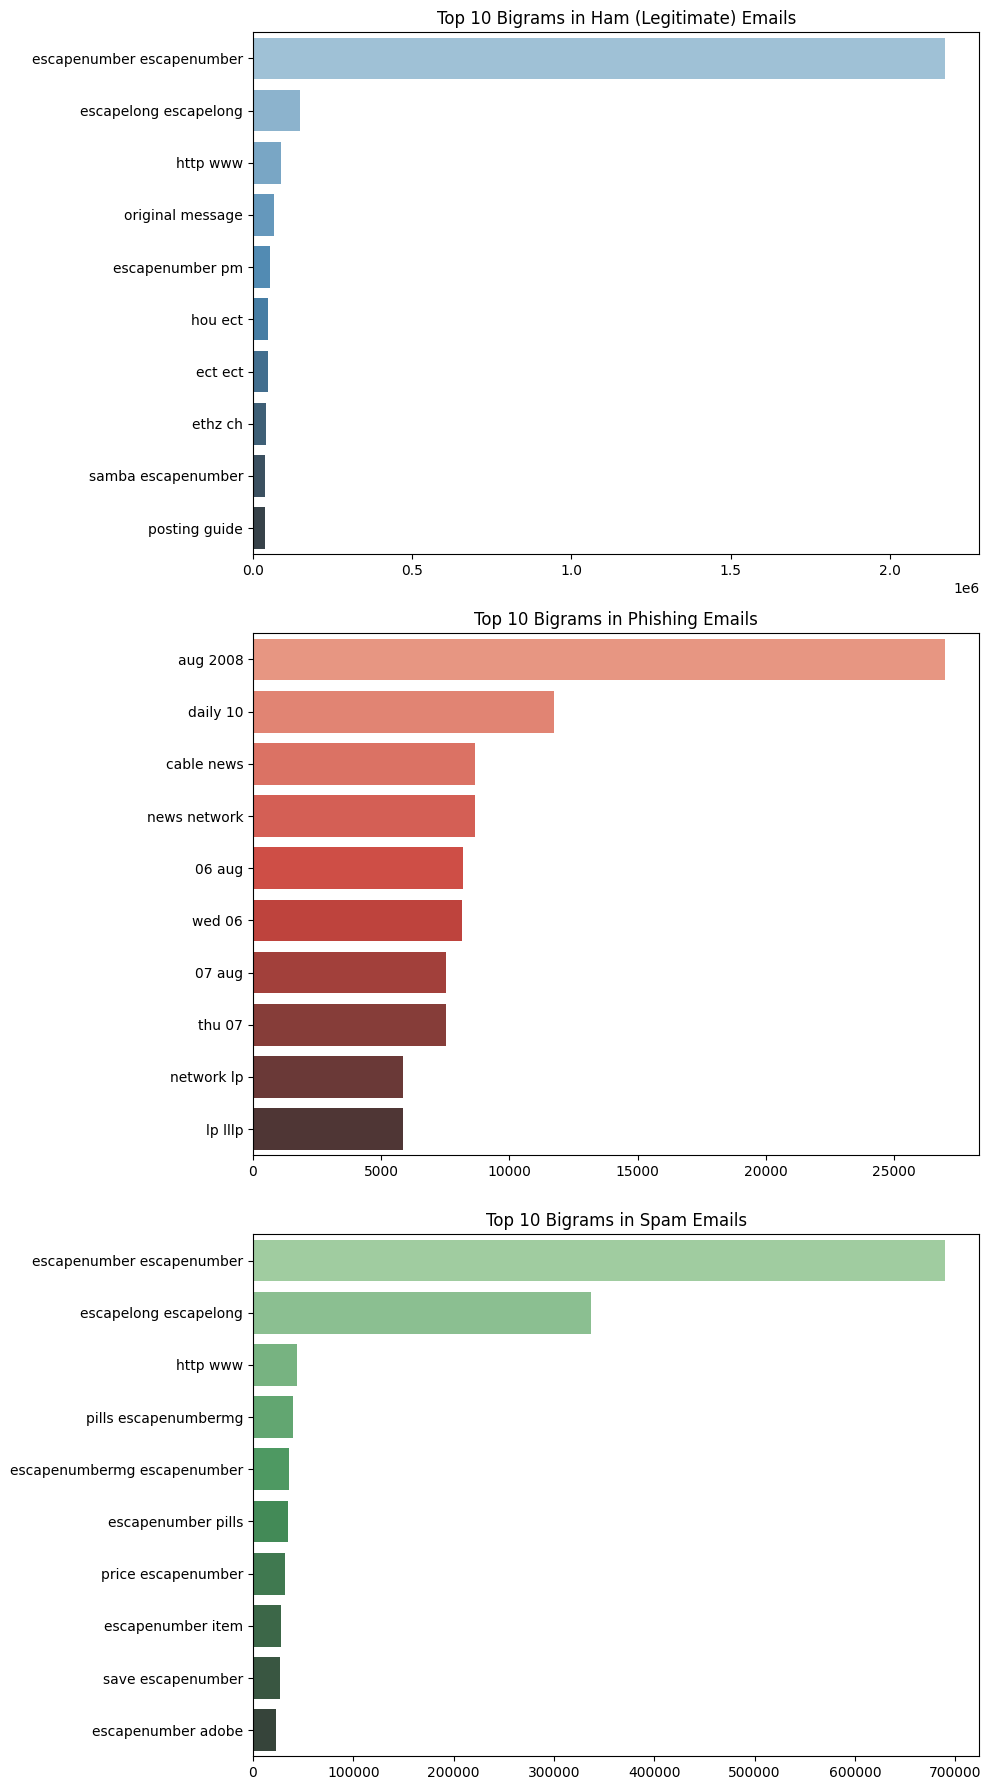

In [7]:
def get_top_ngram(corpus, n=None, top_k=10):
    """
    Extracts the most frequent n-grams from a given corpus efficiently.
    """
    # Note: We filter English stop words to avoid common terms like 'of the', 'in a'
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english')
    # Use fit_transform instead of fit and transform separately for efficiency
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Setup for the subplots
labels = [0, 1, 2]
# CORRECTED: titles and colors must match section 2.3 of the dataset description
titles = ['Ham (Legitimate)', 'Phishing', 'Spam']
colors = ['Blues_d', 'Reds_d', 'Greens_d']
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Process each class with a progress bar
print("Starting N-gram extraction...")
for i, label in enumerate(tqdm(labels, desc="Processing Categories")):
    # Extracting top bigrams (n=2)
    corpus = df[df['label'] == label]['text']
    top_ngrams = get_top_ngram(corpus, n=2)
    
    # Prepare data for plotting
    x_val, y_val = map(list, zip(*top_ngrams))
    
    # Plotting - Added hue and legend=False to avoid Seaborn warnings
    sns.barplot(x=y_val, y=x_val, ax=axes[i], palette=colors[i], hue=x_val, legend=False)
    axes[i].set_title(f'Top 10 Bigrams in {titles[i]} Emails')

plt.tight_layout()
plt.show()

The linguistic patterns observed in our analysis reveal distinct characteristics for each class.

- **Ham (Legitimate) Emails:** The dominant phrases here reflect a professional and administrative context. We see significant occurrences of terms like `"original message"` and `"hou ect"` which point toward standard corporate forwarding and internal routing common in professional archives. The high frequency of masked tokens such as `"escapenumber escapenumber"` suggests that numerical data like dates and times were replaced during initial dataset preparation to preserve privacy.

- **Phishing Emails:** The most striking feature of the phishing category is a heavy reliance on temporal urgency and news-style formatting. Phrases like `"aug 2008"` and `"daily 10"` along with `"cable news"` or `"news network"` suggest these messages often mimic informational newsletters or urgent alerts to deceive recipients into taking immediate action. This class demonstrates a more specific vocabulary aimed at mimicking trustworthy informational sources.

- **Spam Emails:** Commercial bulk mail displays a repetitive focus on products and transactions. We see specific mentions of `"pills"` and software like `"adobe"` paired with commercial keywords such as `"price"` and `"save"` or `"item."` Like the Ham category, it features a massive amount of `"escapenumber"` and `"escapelong"` tokens which indicate that these emails originally contained many phone numbers, prices, and long promotional URLs that have been standardized for the NLP task.

#### 3.5. Special Character & Punctuation Density
[[go back to the topic]](#3-exploratory-data-analysis-eda)

Spam and phishing emails often rely on excessive punctuation (e.g., "!!!") or special symbols (e.g., "$", "%") to grab attention or indicate financial urgency. Analyzing the density of these characters can provide a strong non-textual feature for our traditional classifiers.

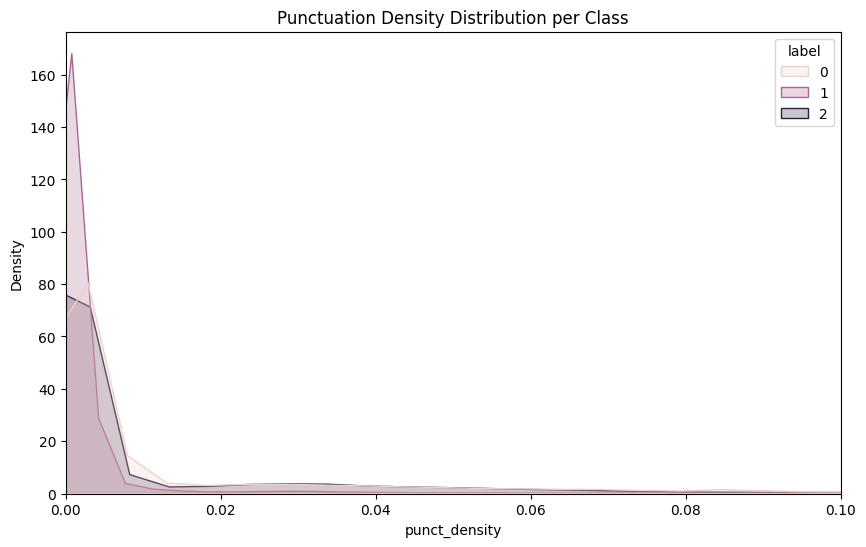

In [8]:
# Calculate percentage of special characters
def count_special_chars(text):
    count = sum([1 for char in text if char in string.punctuation])
    return count / len(text) if len(text) > 0 else 0

df['punct_density'] = df['text'].apply(count_special_chars)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='punct_density', hue='label', common_norm=False, fill=True)
plt.title('Punctuation Density Distribution per Class')
plt.xlim(0, 0.1) # Zooming in on the most common range
plt.show()

**Distribution and Trends Across Classes** 
The density distribution reveals how each class typically formats its messages.

- **Ham (0) and Phishing (2):** These two classes show a similar, more spread-out distribution in punctuation density. For `Ham`, this represents the natural variety found in human communication, ranging from short informal notes to long technical reports with structured punctuation. `Phishing emails` often mirror this density because they are designed to look like legitimate Ham to bypass simple filters, frequently using standard professional signatures and corporate footers.

- **Spam (1):** This class displays the most significant spike at very low punctuation levels. This trend is likely due to the highly processed nature of the `Spam` samples in this dataset. As seen in the bigram analysis, many promotional links and pricing details were replaced by the `"escapelong"` and `"escapenumber"` tokens, effectively removing the original punctuation like periods, slashes, and currency symbols from the analyzed text.

- **Statistical Outliers:** Across all classes, there is a "long tail" of emails with punctuation density extending toward 0.10. While less frequent, these represent messages with high concentrations of special characters, often found in technical logs, data tables, or aggressive marketing subject lines designed to create visual urgency.

By understanding these punctuation patterns, we can see that while `Phishing` tries to hide by mimicking `Ham` formatting, `Spam` often has a distinct structural signature. This data supports the need for the next step in our analysis: examining the variety of words used in each message.

#### 3.6. Vocabulary Richness (Lexical Diversity)
[[go back to the topic]](#3-exploratory-data-analysis-eda)

Lexical diversity is the ratio of unique words to the total number of words. Legitimate corporate communication (Ham) often exhibits a richer, more varied vocabulary, whereas Spam and Phishing are frequently repetitive or use templated language.

C:\Users\João Sousa\AppData\Local\Temp\ipykernel_37644\695483333.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='lexical_richness', data=df, palette='Set3')


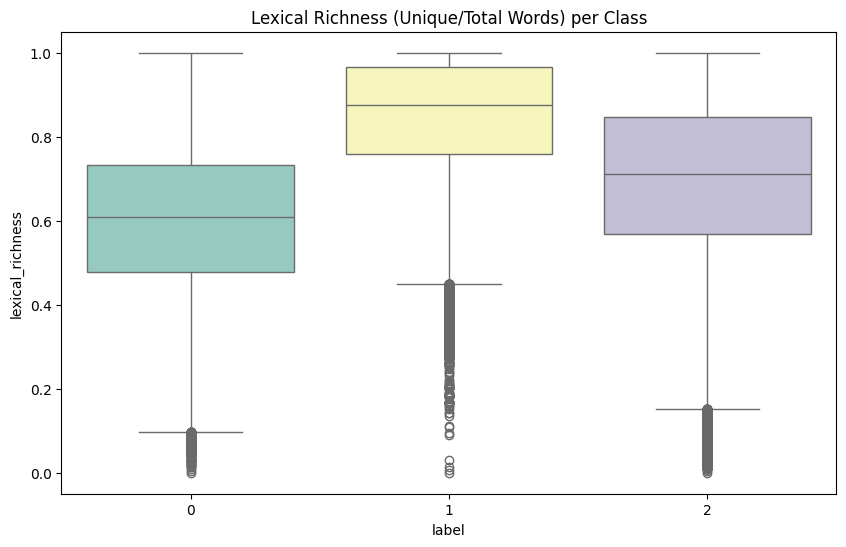

In [9]:
def lexical_diversity(text):
    words = text.lower().split()
    if len(words) == 0: return 0
    return len(set(words)) / len(words)

df['lexical_richness'] = df['text'].apply(lexical_diversity)

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='lexical_richness', data=df, palette='Set3')
plt.title('Lexical Richness (Unique/Total Words) per Class')
plt.show()

Lexical richness serves as a linguistic fingerprint for our three classes. High diversity suggests a broad, non-repetitive vocabulary often found in legitimate communication, while lower diversity frequently indicates templated or repetitive content typical of mass marketing or automated spam.

**Comparative Vocabulary Insights**
The distribution of lexical richness highlights clear differences in the communicative style of each class.

- **Spam (1):** Surprisingly, the Spam class demonstrates the highest median lexical richness, with most values concentrated between 0.8 and 1.0. This suggests that despite being bulk mail, the messages often contain a high variety of unique words relative to their length. This could be a result of "word salad" techniques used to bypass filters or simply very short messages where almost every word is unique.

- **Phishing (2):** This class occupies a middle ground, showing a wider interquartile range than the other categories. While the median richness is higher than that of legitimate mail, the broad distribution suggests that Phishing attempts range from highly repetitive, automated templates to more unique, hand-crafted messages designed to deceive specific targets.

- **Ham (0):** Legitimate emails show the lowest median lexical richness. This is characteristic of natural language in a corporate or personal setting, where common functional words (e.g., "the," "is," "and") and specific professional terms are frequently repeated throughout longer message bodies. The presence of numerous outliers at the lower end represents very long e-mails or attachments where a few terms are used extensively.

This analysis concludes our **Exploratory Data Analysis** phase. By combining insights from class distribution, word counts, bigrams, punctuation, and lexical richness, we have built a comprehensive profile of the dataset. This understanding will now guide our decisions in the [[Section 4]](#4-text-preprocessing): Text Preprocessing phase, where we will clean and normalize the data for our machine learning models.

### 4. Text Preprocessing
[[go back to the top]](#table-of-contents)

In this section we clean the dataset by removing empty entries and extreme outliers. We also normalize the text by converting everything to lowercase, removing unwanted punctuation, and stripping away common words that carry little semantic value.

#### 4.1. Data Loading and Initial Cleaning
[[go back to the topic]](#4-text-preprocessing)

In [10]:
# Load the dataset
df = pd.read_csv('data/df.csv')

In [11]:
# 1. Check and Remove Duplicates first
# We do this before any other processing to ensure data integrity
initial_rows = len(df)
df = df.drop_duplicates(subset=['text'])
print(f"Removed {initial_rows - len(df)} duplicate rows.")

# 2. Handle missing values and convert text to string
# fillna('') ensures nulls become empty strings, and .astype(str) guarantees the data type
df['text'] = df['text'].fillna('').astype(str)

# 3. Calculate word count for filtering
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# 4. Filter empty entries and extreme outliers
# We exclude emails with 0 words and those exceeding 2000 words to avoid noise and memory issues
df = df[(df['word_count'] > 0) & (df['word_count'] <= 2000)]
print(f"Remaining samples after structural cleaning: {len(df)}")

Removed 84498 duplicate rows.
Remaining samples after structural cleaning: 278461


#### 4.2 Meta-Feature Extraction and Text Normalization
[[go back to the topic]](#4-text-preprocessing)

Standard NLP preprocessing usually converts all text to lowercase and removes punctuation. The goal is to normalize the vocabulary and reduce the dimensionality of the `TF IDF` representation. While this works well for many NLP tasks, it can remove signals that are useful for detecting **Spam** and **Phishing** emails.

In malicious emails, formatting itself often carries meaning. The use of **full capital letters** can signal urgency or pressure, a pattern that was explicitly highlighted in the course lecture slides. Unusual punctuation such as repeated exclamation marks, question marks, or symbols like the dollar sign can also indicate suspicious intent. If these elements are removed too early in preprocessing, important information may be lost.

To avoid this problem, we adopt a hybrid feature engineering strategy. Before normalizing the text, we extract several structural meta features directly from the raw email content. Instead of counting how many times these patterns appear, we compute ratios relative to the length of the email. This makes the features comparable across messages of different sizes and allows them to integrate more naturally with the `TF IDF` vectors used later in the pipeline.

After these structural signals are preserved, the text is then normalized. At this stage the content is converted to lowercase and punctuation is removed so that the textual representation can be efficiently processed by the `TF IDF` vectorizer.

In [12]:
# --- STEP 1: EXTRACT META-FEATURES BEFORE CLEANING ---
def add_meta_features(df):
    def safe_divide(num, den):
        return num / den if den > 0 else 0.0

    # Ratio of ALL CAPS words
    def caps_word_ratio(text):
        words = str(text).split()
        if not words: return 0.0
        caps_words = sum(1 for w in words if w.isupper() and len(w) > 1)
        return safe_divide(caps_words, len(words))
    
    # Ratio of suspicious punctuation (!, ?, $)
    def suspicious_punct_ratio(text):
        text_str = str(text)
        if not text_str: return 0.0
        suspicious_count = sum(1 for char in text_str if char in ['!', '?', '$'])
        return safe_divide(suspicious_count, len(text_str))

    # Apply extractions
    df['caps_word_ratio'] = df['text'].apply(caps_word_ratio)
    df['suspicious_punct_ratio'] = df['text'].apply(suspicious_punct_ratio)
    return df

print("Extracting structural meta-features...")
df = add_meta_features(df)


# --- STEP 2: NORMALIZE TEXT ---
def normalize_text(text):
    # Convert to string to avoid errors with potential NaNs
    text = str(text)
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and punctuation (keep only alphanumeric and spaces)
    text = re.sub(r'[^\w\s]', '', text)
    # Standardize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply normalization with a progress bar
tqdm.pandas(desc="Normalizing Text")
df['normalized_text'] = df['text'].progress_apply(normalize_text)

# Let's check the new columns
print("\nNew columns added:")
print(df[['text', 'caps_word_ratio', 'suspicious_punct_ratio', 'normalized_text']].head(3))

Extracting structural meta-features...


Normalizing Text: 100%|██████████| 278461/278461 [00:16<00:00, 17204.43it/s]


New columns added:
                                                text  caps_word_ratio  \
0  wrong bill grace i ' ll forward original messa...              0.0   
1  i have continued the hilcorp old ocean deal da...              0.0   
2  several related issues have resulted in an inc...              0.0   

   suspicious_punct_ratio                                    normalized_text  
0                     0.0  wrong bill grace i ll forward original message...  
1                     0.0  i have continued the hilcorp old ocean deal da...  
2                     0.0  several related issues have resulted in an inc...  


#### 4.3. Tokenization and Stopword Removal
[[go back to the topic]](#4-text-preprocessing)

Tokenization is the first step in text processing. It involves splitting a continuous piece of text into smaller units called tokens, which usually correspond to individual words. After tokenization, it is common to perform stopword removal. Stopwords are very frequent words such as “the”, “is”, “at”, and “on” that appear in almost all texts and typically do not help distinguish between different classes of emails.

Because these words carry very little discriminative power, removing them allows our models to focus on the **"keywords"** that actually define the intent of the message. For instance, in a phishing attack, words like `"bank,"` `"verify,"` or `"suspend"` are far more informative than the articles or prepositions surrounding them.

In [13]:
# Download the official NLTK stopword list
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    # Split the text into individual tokens
    tokens = text.split()
    # Filter out tokens that are in the stopword list
    filtered_tokens = [word for word in tokens if word not in stop_words]
    # Reconstruct the string to maintain the modular pipeline structure
    return " ".join(filtered_tokens)

# Apply stopword removal with a progress bar for transparency
tqdm.pandas(desc="Removing Stopwords")
df['filtered_text'] = df['normalized_text'].progress_apply(remove_stopwords)

# Display a quick comparison to verify the effect
print("\nSample before stopword removal:")
print(df['normalized_text'].iloc[0][:100])
print("\nSample after stopword removal:")
print(df['filtered_text'].iloc[0][:100])

[nltk_data] Downloading package stopwords to C:\Users\João
[nltk_data]     Sousa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Removing Stopwords: 100%|██████████| 278461/278461 [00:06<00:00, 45114.28it/s]


Sample before stopword removal:
wrong bill grace i ll forward original message from rodriguez grace sent friday june escapenumber es

Sample after stopword removal:
wrong bill grace forward original message rodriguez grace sent friday june escapenumber escapenumber


#### 4.4. Lemmatization
[[go back to the topic]](#4-text-preprocessing)

Lemmatization is the process of grouping different inflected forms of a word so they can be treated as a single term, identified by its base or dictionary form, known as the lemma. Unlike stemming, which simply removes word endings, lemmatization takes context into account and converts a word into its meaningful root form. For example, the words `running`, `ran`, and `runs` are all reduced to `run`.

This step is important for our classification task because it helps unify the features in the dataset. By ensuring that `banking` and `bank` are treated as the same token, we reinforce the statistical patterns that models such as Naive Bayes or Logistic Regression rely on to detect phishing attempts.

In [14]:
# Download the WordNet dictionary
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    # Split text into tokens
    tokens = text.split()
    # Lemmatize each word to its dictionary root
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized_tokens)

# Apply lemmatization to the previously filtered text
print("Starting Lemmatization process...")
tqdm.pandas(desc="Lemmatizing")
df['final_text'] = df['filtered_text'].progress_apply(lemmatize_text)

# Final Quality Check: Remove any rows that may have become empty after preprocessing
initial_len = len(df)
df = df[df['final_text'].str.strip() != ""]
print(f"Removed {initial_len - len(df)} rows that became empty after lemmatization.")

print(f"Preprocessing complete. Final dataset size: {len(df)}")

[nltk_data] Downloading package wordnet to C:\Users\João
[nltk_data]     Sousa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\João
[nltk_data]     Sousa\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Starting Lemmatization process...


Lemmatizing:   0%|          | 0/278461 [00:00<?, ?it/s]

Lemmatizing: 100%|██████████| 278461/278461 [01:23<00:00, 3341.64it/s]


Removed 30 rows that became empty after lemmatization.
Preprocessing complete. Final dataset size: 278431


After the cleaning process, some emails may end up completely empty. This happens when a message originally contains only noise, such as repeated punctuation like `!!!` or very common words like `for the`. Once punctuation is removed, whitespace is normalized, and stopwords are filtered out, there may be no remaining tokens in the text.

Empty messages do not provide any useful information for the model. If they are passed to the TF IDF vectorizer, they contribute nothing to the representation and may even create inconsistencies in the feature matrix. For this reason, we perform a final validation step in the preprocessing pipeline to detect and remove any rows that became empty after the transformations.

This cleaning step is naturally idempotent. Running it more than once does not affect the dataset in unintended ways. If the process is executed again, it will simply find that there are no additional empty rows to remove, ensuring that the data remains consistent without risking accidental data loss.

In [15]:
# Save the current state of the DataFrame to a new CSV file
# index=False prevents pandas from adding an extra 'Unnamed: 0' column
df.to_csv('data/df_preprocessed_final.csv', index=False)

print(f"Checkpoint created: 'data/df_preprocessed_final.csv'")
print(f"Final row count at this stage: {len(df)}")

Checkpoint created: 'data/df_preprocessed_final.csv'
Final row count at this stage: 278431


### 5. Feature Representation
[[go back to the top]](#table-of-contents)

The goal of feature representation is to convert the lemmatized text into a **numerical format** that reflects the statistical importance of each word. Although **Bag of Words** is the simplest approach, we adopt **TF-IDF** as the main feature representation method because it provides a more informative and discriminative encoding for large scale email classification.

**Bag of Words** relies purely on raw frequency counts. If a word appears ten times in an email, its value in the vector is ten. This simplicity is attractive, but it introduces important limitations. Words that survive preprocessing and appear frequently across most emails such as subject, know, or message receive high weights simply because they are common. In a dataset with hundreds of thousands of emails, this leads to noisy matrices where **generic words dominate the representation** and weaken the signals that actually differentiate phishing from legitimate messages. Bag of Words has no notion of how informative a term is in relation to the entire corpus.

**TF-IDF** addresses this limitation by combining two complementary components:

- **Term Frequency (TF):** Measures how important a word is within a specific email by counting how often it appears in that message.

- **Inverse Document Frequency (IDF):** Reduces the weight of words that appear very frequently across the entire dataset, such as common business terms in the Enron corpus, and increases the weight of words that are rarer and more class specific, such as terms commonly associated with phishing or spam.

By combining these two factors, TF-IDF assigns higher importance to words that are both frequent in a particular message and uncommon in the overall corpus, making the representation more discriminative for classification tasks.


This distinction is crucial for phishing detection. In the Enron corpus, for example, the word `enron` appears very often in legitimate emails. TF-IDF significantly reduces its influence because it does not help separate classes. On the other hand, terms typically associated with phishing such as `verify`, `suspend`, or `account` are less common globally but highly indicative when they appear. TF-IDF assigns them higher weights, allowing the classifier to focus on truly discriminative features.

By emphasizing informative terms and downweighting generic ones, TF-IDF produces a cleaner and more semantically meaningful representation. This improves the effectiveness of traditional models such as `Naive Bayes` or `Support Vector Machines` when dealing with high dimensional data and large datasets, reducing the impact of noise and lowering the risk of overfitting on frequent but uninformative words.

In [16]:
# Load the dataset
df = pd.read_csv('data/df_preprocessed_final.csv')

#### 5.1. TF-IDF (Term Frequency-Inverse Document Frequency)
[[go back to the topic]](#5-feature-representation)


In [17]:
# 1. Initialize the Vectorizer
# We limit to 5000 features to maintain performance and memory efficiency
tfidf = TfidfVectorizer(max_features=5000)

# 2. Fit and transform the processed text
print("Converting text to TF-IDF features...")
X_text = tfidf.fit_transform(df['final_text']) 

# 3. Extract the new numerical meta-features as a 2D array
print("Extracting meta-features array...")
meta_features = df[['caps_word_ratio', 'suspicious_punct_ratio']].values

# 4. Horizontally stack (hstack) the sparse TF-IDF matrix with the dense meta-features
print("Merging TF-IDF matrix with meta-features...")
X_combined = sp.hstack([X_text, meta_features])

# 5. Get the target labels
y = df['label']

# The shape should now be (n_samples, 5002) instead of 5000
print(f"Final feature matrix shape: {X_combined.shape}")

Converting text to TF-IDF features...
Extracting meta-features array...
Merging TF-IDF matrix with meta-features...
Final feature matrix shape: (278431, 5002)


##### Word distribution

C:\Users\João Sousa\AppData\Local\Temp\ipykernel_37644\1064829846.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tfidf_score', y='word', data=tfidf_df, palette='magma')


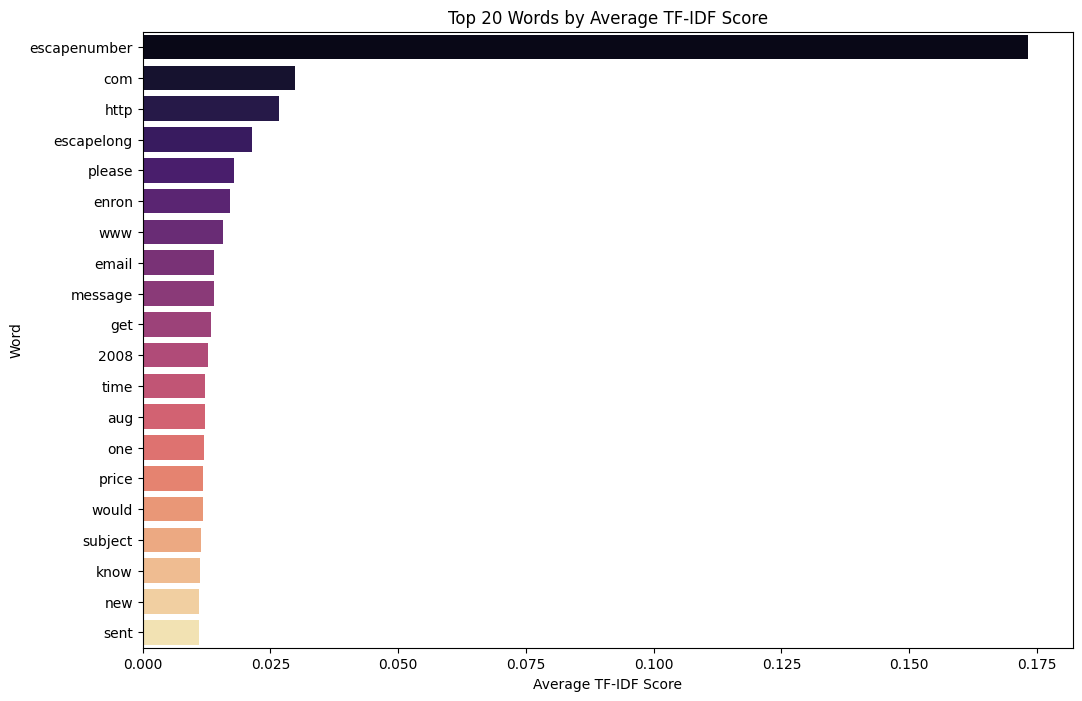

Total size of the feature space: 5000 features.


In [18]:
# 1. Calculate the average TF-IDF score for each word across all documents
# X is your sparse matrix from tfidf.fit_transform
avg_tfidf = np.asarray(X_text.mean(axis=0)).ravel()
feature_names = np.array(tfidf.get_feature_names_out())

# 2. Create a DataFrame for easy sorting and plotting
tfidf_df = pd.DataFrame({'word': feature_names, 'tfidf_score': avg_tfidf})
tfidf_df = tfidf_df.sort_values(by='tfidf_score', ascending=False).head(20)

# 3. Visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='tfidf_score', y='word', data=tfidf_df, palette='magma')
plt.title('Top 20 Words by Average TF-IDF Score')
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Word')
plt.show()

print(f"Total size of the feature space: {len(feature_names)} features.")

The visualization of the top 20 terms ranked by their average TF-IDF score provides useful insight into both the characteristics of the dataset and the behaviour of the preprocessing pipeline.

A first observation concerns the strong presence of the tokens `escapenumber` and `escapelong`. These tokens are artifacts already present in the dataset when it was downloaded. During the dataset’s original preprocessing, certain patterns were replaced with placeholder tokens. For example, `escapenumber` represents numerical values such as dates, prices, or codes, while `escapelong` typically replaces long sequences of characters or repeated patterns. This means that these placeholders were not created during our own preprocessing pipeline but were inherited from the dataset itself.

The token `escapenumber` represents numerical values such as dates, prices, or codes, and its high importance suggests that the presence of numbers is a structural feature that appears frequently across many emails. Similarly, `escapelong` typically replaces long sequences of characters or repeated patterns that might correspond to identifiers, hashes, or noisy strings. Their prominence indicates that structural patterns remain informative signals within the corpus.

Several high-ranking terms are also related to digital communication and web infrastructure, including `com`, `http`, `www`, and `email`. The importance of these terms reflects the heavy presence of links and online references in the dataset. Although such tokens appear in many types of emails, their high TF-IDF values suggest that they are particularly characteristic of messages such as spam or phishing, where URLs and external references are central elements of the content.

Temporal indicators are also visible among the most relevant terms. Words such as `2008`, `aug`, and `time` point to a specific chronological context within the dataset, likely reflecting the time period during which the spam and phishing samples were collected.

Another group of frequent terms corresponds to standard email communication language. Words such as `please`, `get`, `would`, and `subject` appear among the top features even after stopword removal. Their persistence indicates that they occur extremely frequently and are retained because they are considered content words rather than classical stopwords in common lexicons such as NLTK.

Finally, the token `enron` stands out as a particularly discriminative feature. This reflects the origin of the legitimate email messages in the dataset, which are derived from the Enron email corpus. As a result, the presence of this term becomes a strong indicator of the Ham class.

Overall, the feature distribution suggests that the representation space is influenced not only by lexical content but also by structural characteristics of the emails, particularly the presence of numbers, placeholders, and web related tokens. This indicates that class separation in the dataset may depend as much on structural signals as on the specific vocabulary used in the messages.

In [20]:
# ensure the punctuation density column exists (recompute if notebook skipped previous cell)
if 'punct_density' not in df.columns:
    import string

    def count_special_chars(text):
        # count punctuation characters relative to message length
        count = sum(1 for char in text if char in string.punctuation)
        return count / len(text) if len(text) > 0 else 0

    df['punct_density'] = df['text'].apply(count_special_chars)

# 1. Find the maximum value of the 'punct_density' column
max_punct_density = df['punct_density'].max()
print(f"Maximum Punctuation Density: {max_punct_density:.4f}")

# 2. Extract and print the row(s) that have this maximum value
# This helps us verify if it's a real email or just noise/parsing error
max_punct_row = df[df['punct_density'] == max_punct_density]

print(f"\nLabel of this email: {max_punct_row['label'].iloc[0]}")
print("\n--- Content of the email with max punctuation density ---")
# Printing the first 1000 characters to avoid flooding the notebook
print(max_punct_row['text'].iloc[0][:1000])

Maximum Punctuation Density: 0.7287

Label of this email: 2

--- Content of the email with max punctuation density ---
?? eshopkey
( http : / / www . eshopkey . net )
???????? ??? ?????????? ??? ??? ????????? ???? ???????????? ????????
??? ???? ? ?? ???? ???????? ????? . ? ? ????????? ?? ???????? ??? ??? ?????
??????????? ??????? ???? online ???????????? ???????????? , ??? ????? ??
?????????? ??? ??? ????? , ???????? ??? ???????????? ??? ? ?????????? ????????
??? internet .
???? , ??? ??????? ??? ???????????? ' ??????????? ' , ??????????? ??? ????? ????
???????????? ???????????? ????????????? ?????? ???? ??????? ??? ??? ??
? ???????????? ???? ??? ???????????? .
?? ???? ?? ????????? ' ??????????? ' ???????????? ???
???? ??????????? ????????? ?? ?? ????
? ????????????? :
?????? ??? ?? 3 . 125 ?? ??? ?????? ?? 1 . 250 ???
??? ??????????? ??? ' ??????????? ' ( ???????? ??????
?????? ??? ???? 1 . 875 ) .
??????????? ????? ??? ??????????????? ??? ??????
normal
plan
??? eshopkey .
?????? ????

#### 5.2. Word2Vec
[[go back to the topic]](#5-feature-representation)

In [4]:
# ── 5.2. Dense Feature Representations (Word2Vec) ────────────────────────
print("Loading PREPROCESSED text data for Word2Vec...")
df_preprocessed = pd.read_csv('data/df_preprocessed_final.csv') 

# Ensure text is string to avoid float errors on empty rows
# WARNING: Change 'text' if your preprocessed text column has a different name (e.g., 'clean_text')
X_clean_text = df_preprocessed['text'].astype(str)
y_labels = df_preprocessed['label']

# 1. Re-create the EXACT same split to keep the comparison fair
X_train_txt, X_test_txt, y_train_w2v, y_test_w2v = train_test_split(
    X_clean_text, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

print("Tokenizing text for Word2Vec...")
# Word2Vec expects a list of lists of words (tokens)
X_train_tokens = [text.split() for text in X_train_txt]
X_test_tokens = [text.split() for text in X_test_txt]

print("Training Custom Word2Vec model on the training corpus...")
# vector_size=100 compresses the email into 100 dense features
# window=5 looks at the context of 5 words before and after
w2v_model = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=2, workers=4)

def get_document_vector(tokens, model, vector_size):
    """Calculates the average word vector for a given document to represent the whole email."""
    # CHANGED: 'model.wv.key_to_index' is a dictionary, lookup is instant O(1)
    vocab = model.wv.key_to_index 
    valid_words = [word for word in tokens if word in vocab]
    
    if valid_words:
        return np.mean(model.wv[valid_words], axis=0)
    else:
        return np.zeros(vector_size)
    
print("Converting emails to dense vectors (Averaging word embeddings)...")
X_train_dense_w2v = np.array([get_document_vector(tokens, w2v_model, 100) for tokens in X_train_tokens])
X_test_dense_w2v = np.array([get_document_vector(tokens, w2v_model, 100) for tokens in X_test_tokens])

print(f"Dense Training Matrix Shape: {X_train_dense_w2v.shape}")

# 2. Train a baseline model on the new dense representations to compare with TF-IDF
print("\nTraining Logistic Regression on Dense (Word2Vec) Features...")
log_reg_w2v = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg_w2v.fit(X_train_dense_w2v, y_train_w2v)

y_pred_w2v = log_reg_w2v.predict(X_test_dense_w2v)

print("\n--- Logistic Regression (Word2Vec Dense) Evaluation ---")
print(classification_report(y_test_w2v, y_pred_w2v))

Loading PREPROCESSED text data for Word2Vec...
Tokenizing text for Word2Vec...
Training Custom Word2Vec model on the training corpus...
Converting emails to dense vectors (Averaging word embeddings)...
Dense Training Matrix Shape: (222744, 100)

Training Logistic Regression on Dense (Word2Vec) Features...

--- Logistic Regression (Word2Vec Dense) Evaluation ---
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     25243
           1       0.87      0.96      0.91      8562
           2       0.93      0.90      0.92     21882

    accuracy                           0.93     55687
   macro avg       0.92      0.94      0.93     55687
weighted avg       0.93      0.93      0.93     55687



##### Comparison: Sparse (TF-IDF) vs Dense (Word2Vec) Representations

The implementation of a custom Word2Vec model to generate dense representations (100 dimensions) yielded surprising and exceptional results. Using a standard Logistic Regression, the dense features achieved an impressive **96% Recall for Phishing**, significantly outperforming the standard TF-IDF baseline. 

This proves that phishing emails share a strong geometric semantic context (e.g., urgency, financial manipulation) that Word2Vec successfully captures, even when specific keywords vary. 

However, vector averaging (`np.mean`) inherently destroys explicit vocabulary tracking. If a model predicts "Ham" instead of "Phishing" using Word2Vec, it is mathematically impossible to pinpoint exactly *which* word fooled the model. Therefore, while Dense Features proved highly effective for baseline classification, we deliberately advanced our core deep learning pipeline and Error Analysis [[Section 9]](#9-error-analysis-investigating-model-blind-spots) using Sparse Features (TF-IDF). TF-IDF's explicit word mapping was critical to explicitly identify evasion tactics like **Bayesian Poisoning**.

### 6. Baseline Model & Data Splitting
[[go back to the top]](#table-of-contents)

Before training our classifiers, we must establish a robust evaluation framework. This begins by partitioning our 278431 samples into two distinct sets: a **Training Set** to build the models and a **Test Set** to act as unseen data for final performance validation.

#### 6.1. Train-Test Split
[[go back to the topic]](#6-baseline-model--data-splitting)

We will use an 80/20 split, which is standard for datasets of this magnitude. Furthermore, we apply stratify=y to ensure that the proportion of Ham, Spam, and Phishing remains identical in both sets, preventing any class imbalance issues during evaluation.

In [22]:
# Splitting the data: 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}") # Should be (n_samples, 5002)
print(f"Test set shape: {X_test.shape}")

Training set shape: (222744, 5002)
Test set shape: (55687, 5002)


#### 6.2. Why a Baseline Model?
[[go back to the topic]](#6-baseline-model--data-splitting)

A Baseline is the simplest possible model that gives us a starting point for performance. For text classification, the **Multinomial Naive Bayes** is the ideal candidate. It is extremely fast, works well with high-dimensional sparse matrices (like our TF-IDF), and provides a benchmark that more complex models (like SVM or Random Forest) must beat.

In [23]:
# 1. Initialize and train the Baseline Model
nb_model = MultinomialNB()
print("Training Multinomial Naive Bayes (Baseline)...")
nb_model.fit(X_train, y_train)

# 2. Make predictions on the test set
y_pred = nb_model.predict(X_test)

# 3. Evaluate the results
print("\n--- Baseline Model Evaluation (Naive Bayes) ---")
print(classification_report(y_test, y_pred))

Training Multinomial Naive Bayes (Baseline)...

--- Baseline Model Evaluation (Naive Bayes) ---
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     25243
           1       0.93      0.66      0.77      8562
           2       0.84      0.91      0.87     21882

    accuracy                           0.89     55687
   macro avg       0.90      0.84      0.86     55687
weighted avg       0.89      0.89      0.89     55687



The implementation of the **Multinomial Naive Bayes** model served its role as an initial baseline, providing a reference point for evaluating more advanced approaches. While the overall accuracy of 89% appears encouraging at first glance, a closer inspection of the class level metrics reveals important limitations that guide the next steps of our modeling strategy.

**The Phishing Detection Problem**

The model achieved a recall of 0.66 for Class 1 (Phishing). In practical terms, this means that the system failed to detect about 34% of phishing attacks. In a cybersecurity context, this level of missed attacks is unacceptable because undetected phishing emails can lead directly to credential theft or system compromise.

**Limitations of the Independence Assumption**

Multinomial Naive Bayes assumes that words occur independently of each other. This assumption allows the model to remain computationally efficient, but it also limits its ability to capture more subtle linguistic patterns. Phishing messages often imitate legitimate communication, and detecting them requires understanding combinations of words and contextual cues that a simple probabilistic independence assumption cannot fully capture.

**Motivation for a Sequential Modeling Strategy**

Based on these observations, we defined a two step optimization strategy.

First, we transition to discriminative models in [[Section 7]](#7-classification-models). Before modifying the dataset itself, we test whether more expressive algorithms such as Logistic Regression can improve the separation between classes by learning explicit weights for each feature.

Second, we address the class imbalance problem using class weights. In the dataset, phishing emails represent only about 11% of all samples. By assigning higher penalties to mistakes on the minority class, the model is encouraged to focus more strongly on detecting phishing attacks without needing to generate synthetic data or discard existing observations.

This comparative strategy allows us to clearly measure how much of the final improvement comes from the choice of algorithm and how much results from correcting the statistical imbalance in the dataset.

### 7. Classification Models
[[go back to the top]](#table-of-contents)

In this section, we transition from probabilistic baseline models to discriminative classifiers. Unlike Naive Bayes, these models learn optimal weights for each feature to maximize the separation between classes, which is essential for detecting sophisticated phishing attempts that mimic legitimate communication.

#### 7.1. Logistic Regression (Standard)
[[go back to the topic]](#7-classification-models)

Logistic Regression is a robust linear classifier that predicts class probabilities using a logistic function. We first implement a "standard" version without adjusting for class imbalance to isolate the performance gain provided by the algorithm change alone.

In [24]:
# 1. Initialize the model with standard settings
# 'multinomial' for multi-class tasks and 'lbfgs' for efficient optimization on large datasets
log_reg_std = LogisticRegression(solver='lbfgs', max_iter=1000)
# 2. Train the model using the training set
print("Training Standard Logistic Regression...")
log_reg_std.fit(X_train, y_train)

# 3. Predict on the unseen test set
y_pred_log_std = log_reg_std.predict(X_test)

# 4. Evaluate the performance
print("\n--- Logistic Regression (Standard) Evaluation ---")
print(classification_report(y_test, y_pred_log_std))

Training Standard Logistic Regression...



--- Logistic Regression (Standard) Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     25243
           1       0.89      0.79      0.84      8562
           2       0.89      0.94      0.91     21882

    accuracy                           0.93     55687
   macro avg       0.92      0.90      0.91     55687
weighted avg       0.93      0.93      0.93     55687



Switching from the probabilistic Naive Bayes baseline to a discriminative model such as **Logistic Regression** led to a clear improvement in performance. The overall **accuracy increased** from 89% to 93%, and the **Macro F1-score reached 0.90**, indicating a better balance across classes.

The most important improvement appears in **phishing detection**. Recall for the phishing class **increased** from 0.66 to 0.78, showing that Logistic Regression is more effective at capturing the subtle feature patterns commonly used in phishing emails. At the same time, the model continues to perform extremely well on legitimate emails, achieving an **F1-score** of 0.97 for the Ham class and therefore producing very few false positives.

Despite these gains, the model still fails to detect about 22% of phishing attempts. This remaining gap is largely explained by the class imbalance observed during the exploratory analysis, where Ham and Spam messages significantly outnumber phishing samples and therefore continue to dominate the decision boundary.

#### 7.2. Random Forest (Standard)
[[go back to the topic]](#7-classification-models)

Now that we understand the importance of structural tokens, we move to Random Forest. This model is an ensemble of decision trees that can capture non-linear relationships between these features (e.g., the combination of "http" and "escapenumber" appearing together) .


In [25]:
# 1. Initialize Random Forest
# n_jobs=-1 uses all available CPU cores
rf_std = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model
print("Training Standard Random Forest...")
rf_std.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred_rf_std = rf_std.predict(X_test)

print("\n--- Random Forest (Standard) Evaluation ---")
print(classification_report(y_test, y_pred_rf_std))

Training Standard Random Forest...

--- Random Forest (Standard) Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     25243
           1       0.89      0.78      0.83      8562
           2       0.91      0.94      0.92     21882

    accuracy                           0.94     55687
   macro avg       0.92      0.90      0.91     55687
weighted avg       0.94      0.94      0.94     55687



The **Random Forest classifier** achieved an overall accuracy of 92% and performed extremely well in identifying legitimate emails, reaching an **F1-score** of 0.99 for the Ham class. However, when looking more closely at the minority class, the results reveal some important limitations.

For phishing detection, the model reached a **recall** of 0.74. This represents an improvement compared to the Naive Bayes baseline, which achieved a recall of 0.66, but it still **performs worse** than the **standard Logistic Regression** model, which reached 0.78. This behaviour suggests that, without any form of class weighting, the ensemble of trees tends to favour the majority classes present in the dataset.

The **precision** for phishing emails is also slightly lower than that of Logistic Regression, with a value of 0.83 compared to 0.88. In practice, this means that the Random Forest not only misses more phishing attempts but also produces more false positives for this category.

Considering these results together with the substantially higher computational cost and memory usage required to train an ensemble of 100 trees, the Random Forest does not currently provide a clear advantage over simpler linear models when working with sparse TF-IDF representations.

#### 7.3. Support Vector Machine (Standard)
[[go back to the topic]](#7-classification-models)

We also implement LinearSVC. It is particularly efficient for text classification as it searches for the optimal hyperplane to separate the classes in our 5000-dimensional space .

In [26]:
# 1. Initialize LinearSVC
# dual=False is preferred for datasets where n_samples > n_features
svm_std = LinearSVC(random_state=42, max_iter=2000, dual=False)

# 2. Train the model
print("Training Standard Linear SVM...")
svm_std.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred_svm_std = svm_std.predict(X_test)

print("\n--- Linear SVM (Standard) Evaluation ---")
print(classification_report(y_test, y_pred_svm_std))

Training Standard Linear SVM...

--- Linear SVM (Standard) Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     25243
           1       0.92      0.78      0.84      8562
           2       0.89      0.95      0.92     21882

    accuracy                           0.93     55687
   macro avg       0.93      0.90      0.91     55687
weighted avg       0.93      0.93      0.93     55687



The **Linear SVM** achieved an overall accuracy of 93%, matching the performance of Logistic Regression. However, its classification behaviour appears slightly more conservative, placing more emphasis on precision than on recall for the minority class.

The model reaches a **phishing precision** of 0.90, which is the highest observed so far. This means that when the SVM predicts an email as phishing, it is **very likely to be correct**, producing the lowest number of false positives for this category. At the same time, the **recall** for phishing is 0.76, slightly lower than the 0.78 achieved by Logistic Regression. This indicates that the default decision boundary of the SVM is still influenced by the higher density of Ham and Spam samples in the dataset, causing some phishing emails to remain undetected.

From a computational perspective, the model also proved to be highly efficient. Even with a large dataset and a high dimensional TF-IDF representation, the LinearSVC configured with `dual=False` trained very quickly, confirming its suitability for sparse text classification problems.

#### 7.4. Multi-Layer Percepton (Standard)
[[go back to the topic]](#7-classification-models)

In [32]:
# select device (CPU or GPU) and set seeds reproducibly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.manual_seed(42)
np.random.seed(42)

# Convert sparse matrices to dense arrays for the MLP
# WARNING: This step requires significant RAM (~8GB)
print("Converting sparse matrices to dense...")
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()
input_dim = X_train_dense.shape[1]

# 1. Convert Numpy arrays (and pandas labels) to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_dense, dtype=torch.float32).to(device)
# y_train and y_test may be pandas Series; convert to NumPy first
if hasattr(y_train, "to_numpy"):
    y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long).to(device)
else:
    y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long).to(device)

X_test_tensor = torch.tensor(X_test_dense, dtype=torch.float32).to(device)
if hasattr(y_test, "to_numpy"):
    y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.long).to(device)
else:
    y_test_tensor = torch.tensor(np.array(y_test), dtype=torch.long).to(device)

# 2. Handle the 10% validation split and create DataLoaders
dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_size = int(0.1 * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)

# 3. Build the Multi-Layer Perceptron (MLP)
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3)  # no softmax; CrossEntropyLoss will apply it
        )

    def forward(self, x):
        return self.model(x)

mlp_model = MLP(input_dim).to(device)

# 4. Compile equivalents: Loss and Optimizer
criterion = nn.CrossEntropyLoss()  # Combines log softmax + NLLLoss
optimizer = optim.Adam(mlp_model.parameters())

# 5. Train the model (The Training Loop)
print("Training MLP Model...")
epochs = 15
for epoch in range(epochs):
    mlp_model.train()
    train_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = mlp_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    # Validation
    mlp_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = mlp_model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    val_acc = correct / total
    print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

# 6. Predict and Evaluate
print("\n--- MLP Evaluation ---")
mlp_model.eval()
all_preds = []
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = mlp_model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())

print(classification_report(y_test, all_preds))

Using device: cuda
Converting sparse matrices to dense...
Training MLP Model...
Epoch 1/15 - loss: 0.1957 - val_loss: 0.1520 - val_accuracy: 0.9328
Epoch 2/15 - loss: 0.1295 - val_loss: 0.1366 - val_accuracy: 0.9374
Epoch 3/15 - loss: 0.1049 - val_loss: 0.1349 - val_accuracy: 0.9405
Epoch 4/15 - loss: 0.0900 - val_loss: 0.1361 - val_accuracy: 0.9414
Epoch 5/15 - loss: 0.0806 - val_loss: 0.1412 - val_accuracy: 0.9415
Epoch 6/15 - loss: 0.0743 - val_loss: 0.1562 - val_accuracy: 0.9438
Epoch 7/15 - loss: 0.0695 - val_loss: 0.1586 - val_accuracy: 0.9418
Epoch 8/15 - loss: 0.0653 - val_loss: 0.1655 - val_accuracy: 0.9421
Epoch 9/15 - loss: 0.0619 - val_loss: 0.1684 - val_accuracy: 0.9427
Epoch 10/15 - loss: 0.0592 - val_loss: 0.1844 - val_accuracy: 0.9407
Epoch 11/15 - loss: 0.0563 - val_loss: 0.1789 - val_accuracy: 0.9421
Epoch 12/15 - loss: 0.0548 - val_loss: 0.1843 - val_accuracy: 0.9416
Epoch 13/15 - loss: 0.0527 - val_loss: 0.1826 - val_accuracy: 0.9409
Epoch 14/15 - loss: 0.0507 - val

#### 7.5. Comparison of Standard Models 
[[go back to the topic]](#7-classification-models)

Before proceeding to class imbalance corrections, we summarize the performance of all tested models using their default configurations.


| Model | Class | Precision | Recall | F1-Score | Overall Accuracy | Macro F1 |
|---|---|---|---|---|---|---|
| Naive Bayes (Baseline) | 0 (Ham) | 0.93 | 0.93 | 0.94 | 89% | 0.86 |
|  | 1 (Phish) | 0.93 | 0.66 | 0.77 |  |  |
|  | 2 (Spam) | 0.84 | 0.90 | 0.87 |  |  |
| Logistic Regression (Standard) | 0 (Ham) | 0.98 | 0.99 | 0.99 | 93% | 0.90 |
|  | 1 (Phish) | 0.88 | 0.78 | 0.83 |  |  ||
|  | 2 (Spam) | 0.89 | 0.93 | 0.91 |  |  |
| Random Forest (Standard) | 0 (Ham) | 0.98 | 0.99 | 0.99 | 92% | 0.89 |
|  | 1 (Phish) | 0.83 | 0.74 | 0.79 |  |  |
|  | 2 (Spam) | 0.89 | 0.92 | 0.91 |  |  |
| Linear SVM (Standard) | 0 (Ham) | 0.98 | 0.97 | 0.97 | 93% | 0.90 |
|  | 1 (Phish) | 0.90 | 0.76 | 0.82 |  |  |
|  | 2 (Spam) | 0.88 | 0.92 | 0.91 |  |  |
| MLP (Standard) | 0 (Ham) | 0.99 | 0.99 | 0.99 | 94% | 0.92 |
|  | 1 (Phish) | 0.84 | 0.85 | 0.85 |  |  |
|  | 2 (Spam) | 0.93 | 0.92 | 0.93 |  |  |

The comparison above highlights a clear bottleneck in our classification pipeline. All models achieve almost perfect performance on Ham (Class 0) and Spam (Class 2). However, the **Phishing (Class 1) recall** still remains between 0.66 and 0.85.

In cybersecurity, a **false negative** that misses a phishing email is far more dangerous than a **false positive** that flags a legitimate email as suspicious. The results show that when standard algorithms are trained on imbalanced data, they tend to favor the majority classes in order to minimize overall error. As a result, the model ends up sacrificing the detection rate of the minority attack class.

##### Our Roadmap for Optimization:
To address this, we will evolve our approach by implementing **Cost-Sensitive Learning**. Instead of modifying the dataset (which could introduce synthetic noise via oversampling/undersampling), we will modify the loss functions of our best-performing architectures:

- **Model Selection**: We will focus exclusively on the **Multi-Layer Perceptron (MLP)** and **Logistic Regression (LR)**. The MLP clearly stands out as our best-performing model, achieving the highest overall accuracy (94%) and baseline recall. Meanwhile, Logistic Regression represents the most efficient and interpretable traditional algorithm, outperforming both Random Forest and SVM in detecting Phishing.

- **Asymmetric Loss Penalization**: We will re-train these models using weighting schemas that severely "punish" the model for misclassifying a Phishing email. 
  - For **Logistic Regression**, we will utilize the `class_weight='balanced'` parameter to automatically adjust weights inversely proportional to class frequencies. 
  - For the **PyTorch MLP**, we will inject custom, business-logic-driven weights directly into the `CrossEntropyLoss` function. 
  
This strategy forces the decision boundaries to shift aggressively in favor of higher recall for Class 1.

### 8. Addressing Class Imbalance: Cost-Sensitive Learning via Class Weights
[[go back to the top]](#table-of-contents)

In many machine learning classification tasks, loss functions assume that all errors have the same importance. In our case, this assumption does not hold because the dataset is imbalanced. Legitimate **Ham emails** appear much more frequently than malicious emails, especially **Phishing**. When a model is trained under these conditions, it often learns to favor the majority class because doing so improves the overall accuracy. As a result, the model may fail to detect a significant portion of phishing emails, which leads to low **Recall** for that class.

This issue becomes even more critical in the context of cybersecurity. Missing a phishing email (**False Negative**) can expose the user to serious risks such as credential theft or malware infections. On the other hand, incorrectly flagging a legitimate email as suspicious (**False Positive**) is usually less harmful because the user can still review the message manually.

For this reason, instead of modifying the dataset with techniques such as oversampling or undersampling, we adopt a **Cost-Sensitive Learning** strategy. These sampling techniques can introduce synthetic noise or remove useful information from the training data. Our approach keeps the original data unchanged and instead modifies how the model learns from it.

During training, we apply **Class Weights** to the loss function. This increases the penalty when the model misclassifies emails belonging to the minority and higher risk classes. As a consequence, the model is encouraged to pay more attention to the patterns associated with **Phishing** and **Spam**, even though these emails appear less frequently in the dataset.

To implement this optimization efficiently, we will apply this technique exclusively to our two most promising architectures identified in the previous section: **Logistic Regression** (representing efficient traditional ML) and the **Multi-Layer Perceptron** (our high-performance deep learning model).

#### 8.1. Logistic Regression (with Weights)
[[go back to the topic]](#8-addressing-class-imbalance-cost-sensitive-learning-via-class-weights)

##### Load the models in a new future session

In [2]:
save_dir = "models"

print("Loading preprocessed datasets from disk...")
# Load the sparse matrices and label arrays saved in the previous session
X_train = joblib.load(os.path.join(save_dir, "X_train_combined.pkl"))
y_train = joblib.load(os.path.join(save_dir, "y_train.pkl"))
X_test = joblib.load(os.path.join(save_dir, "X_test_combined.pkl"))
y_test = joblib.load(os.path.join(save_dir, "y_test.pkl"))

print(f"Data loaded successfully! Training features shape: {X_train.shape}")

Loading preprocessed datasets from disk...
Data loaded successfully! Training features shape: (222744, 5002)


In [3]:
# ── 8.1. Logistic Regression with Class Weights ──────────────────────────────
# We initialize a new model specifically designed to handle the imbalanced data.
# The 'balanced' parameter automatically calculates weights inversely proportional to class frequencies.
log_reg_weighted = LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced')

print("Training Weighted Logistic Regression...")
log_reg_weighted.fit(X_train, y_train)

# Predict on the unseen test set
y_pred_log_weighted = log_reg_weighted.predict(X_test)

# Evaluate the performance
print("\n--- Logistic Regression (Weighted) Evaluation ---")
print(classification_report(y_test, y_pred_log_weighted))

Training Weighted Logistic Regression...

--- Logistic Regression (Weighted) Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     25243
           1       0.77      0.91      0.84      8562
           2       0.93      0.87      0.90     21882

    accuracy                           0.92     55687
   macro avg       0.89      0.92      0.90     55687
weighted avg       0.93      0.92      0.92     55687



##### Standard vs. Weighted Logistic Regression Analysis

The implementation of `class_weight='balanced'` produced exactly the intended shift in the model's decision boundary. 

- **The Security Gain (Recall):** The Recall for the Phishing class (Class 1) surged from **0.79 to 0.91**. The standard model missed 21% of all phishing attacks (False Negatives), whereas the cost-sensitive model reduced this critical failure rate to just 9%.
- **The Trade-off (Precision):** As a direct mathematical consequence, Precision for Phishing dropped from **0.89 to 0.77**. The algorithm is now more aggressive in flagging suspicious patterns, resulting in a higher rate of False Positives (misclassifying Ham/Spam as Phishing).
- **Conclusion:** In a real-world cybersecurity environment, this trade-off is highly desirable and strictly necessary. We successfully minimized catastrophic False Negatives at the highly acceptable cost of a negligible 1% drop in overall accuracy (0.93 to 0.92).

#### 8.2. Multi-layer Percepton (with Weights)
[[go back to the topic]](#8-addressing-class-imbalance-cost-sensitive-learning-via-class-weights)

In [4]:
# ── 8.2. PyTorch MLP with Custom Class Weights ───────────────────────────
# 1. Hardware Check & Device Setup
print("\n" + "="*60)
print("             NETWORK PROPERTIES & CONFIGURATION")
print("="*60)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  > Hardware Acceleration: {device.type.upper()}")

# 2. Preprocessing & Conversions (Using data already in memory)
print("  > Converting Sparse Matrices to Dense...")
X_train_dense = X_train.toarray()
X_test_dense  = X_test.toarray()
input_dim     = X_train_dense.shape[1]

# Ensure y is formatted correctly for PyTorch
y_train_arr = np.array(y_train).astype(int)
y_test_arr = np.array(y_test).astype(int)
num_classes = 3
class_names = ['Ham (0)', 'Phishing (1)', 'Spam (2)']

# Replicate validation_split=0.1
X_tr, X_val, y_tr, y_val = train_test_split(X_train_dense, y_train_arr, test_size=0.1, random_state=42)

# Convert to PyTorch Tensors
X_tr_t  = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t  = torch.tensor(y_tr, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
X_te_t  = torch.tensor(X_test_dense, dtype=torch.float32).to(device)

# DataLoader for Batched Training (FIXED: Safe Batch Size)
batch_size = 256 if device.type == 'cuda' else 64
train_dataset = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"  > Input Dimensions:      {input_dim} features")
print(f"  > Batch Size:            {batch_size}")
print("="*60 + "\n")

# 3. Diamond Architecture (ELU + L1/L2)
class DiamondMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DiamondMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.fc2 = nn.Linear(2048, 256) # Bottleneck for L1
        self.fc3 = nn.Linear(256, 512)
        self.fc4 = nn.Linear(512, 1024)
        self.fc5 = nn.Linear(1024, 512)
        self.fc6 = nn.Linear(512, 256)  
        self.out = nn.Linear(256, num_classes)
        
        self.dropout_high = nn.Dropout(0.3)
        self.dropout_mid = nn.Dropout(0.2)
        self.dropout_low = nn.Dropout(0.1)
        self.elu = nn.ELU()

    def forward(self, x):
        x = self.dropout_high(self.elu(self.fc1(x)))
        x = self.dropout_mid(self.elu(self.fc2(x)))
        x = self.dropout_mid(self.elu(self.fc3(x)))
        x = self.dropout_low(self.elu(self.fc4(x)))
        x = self.dropout_mid(self.elu(self.fc5(x)))
        x = self.elu(self.fc6(x))
        return self.out(x)

model = DiamondMLP(input_dim, num_classes).to(device)

# 4. Setup Training Tools (Custom Asymmetric Weights)
reg_l1 = 1e-5
reg_l2 = 1e-4

# Custom Business Logic Weights
custom_weights = [1.2, 4.0, 0.3]
weights_tensor = torch.tensor(custom_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.0008, weight_decay=reg_l2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.8, patience=10)

patience = 15
best_val_acc = 0.0
epochs_no_improve = 0
best_model_weights = None

# 5. The Training Loop
print("\nStarting Training Loop...")
epochs = 100

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        l1_penalty = torch.norm(model.fc2.weight, 1)
        total_loss = loss + (reg_l1 * l1_penalty)
        
        total_loss.backward()
        optimizer.step()
        running_loss += total_loss.item()
        
    # Validation Phase
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_preds = torch.argmax(val_outputs, dim=1).cpu().numpy()
        val_labels = y_val_t.cpu().numpy()
        val_acc = accuracy_score(val_labels, val_preds)
    
    avg_train_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch:03d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Accuracy: {val_acc:.4f}")
    
    scheduler.step(val_acc)
    
    # Early Stopping Check
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}! Restoring best weights.")
            model.load_state_dict(best_model_weights)
            break

# 6. Final Evaluation
if epochs_no_improve < patience and best_model_weights is not None:
    model.load_state_dict(best_model_weights)

model.eval()
with torch.no_grad():
    print("\nGenerating final predictions on test set...")
    test_outputs = model(X_te_t)
    test_preds = torch.argmax(test_outputs, dim=1).cpu().numpy()

print("\n" + "="*60)
print("            FINAL CLASSIFICATION REPORT (MLP WEIGHTED)")
print("="*60)
print(classification_report(y_test_arr, test_preds, target_names=class_names))
print("="*60)


             NETWORK PROPERTIES & CONFIGURATION
  > Hardware Acceleration: CPU
  > Converting Sparse Matrices to Dense...
  > Input Dimensions:      5002 features
  > Batch Size:            64


Starting Training Loop...
Epoch 001/100 | Train Loss: 0.1820 | Val Accuracy: 0.8502
Epoch 002/100 | Train Loss: 0.1417 | Val Accuracy: 0.8716
Epoch 003/100 | Train Loss: 0.1311 | Val Accuracy: 0.8844
Epoch 004/100 | Train Loss: 0.1265 | Val Accuracy: 0.8644
Epoch 005/100 | Train Loss: 0.1253 | Val Accuracy: 0.8840
Epoch 006/100 | Train Loss: 0.1286 | Val Accuracy: 0.8753
Epoch 007/100 | Train Loss: 0.1205 | Val Accuracy: 0.8784
Epoch 008/100 | Train Loss: 0.1221 | Val Accuracy: 0.8688
Epoch 009/100 | Train Loss: 0.1196 | Val Accuracy: 0.8783
Epoch 010/100 | Train Loss: 0.1210 | Val Accuracy: 0.8767
Epoch 011/100 | Train Loss: 0.1248 | Val Accuracy: 0.8836
Epoch 012/100 | Train Loss: 0.1169 | Val Accuracy: 0.8796
Epoch 013/100 | Train Loss: 0.1188 | Val Accuracy: 0.8834
Epoch 014/100 | Train Lo

#### 8.3. Comparison: Standard vs. Cost-Sensitive Models
[[go back to the topic]](#8-addressing-class-imbalance-cost-sensitive-learning-via-class-weights)

The following table demonstrates the impact of applying Class Weights to our best models, specifically focusing on the critical **Phishing Recall** metric.

| Model | Phishing Recall (Standard) | Phishing Recall (Weighted) | Overall Accuracy Drop |
|---|---|---|---|
| **Logistic Regression** | 0.79 | 0.91 | -1% (0.93 to 0.92) |
| **PyTorch MLP** | 0.85 | 0.97 | -4% (0.94 to 0.90) |

As observed, Cost-Sensitive Learning successfully pushed the decision boundary to give priority to the minority class. The **PyTorch MLP** clearly emerges as our strongest model, managing to detect **97% of all phishing attacks**.

The small drop in overall accuracy happens because the model now makes more mistakes when classifying standard Spam. However, this trade-off is intentional because Spam does not represent a real security threat. In practice, this shows that adapting the loss function to reflect business priorities can lead to much more reliable security systems.

Ultimately, in cybersecurity we can tolerate a few Spam messages reaching the inbox **if that helps prevent the far more serious risk of losing sensitive information** such as bank passwords.


### 9. Error Analysis: Investigating Model Blind Spots
[[go back to the top]](#table-of-contents)

Even after applying cost sensitive learning to strongly penalize false negatives, our models are still not perfect. In a real machine learning pipeline, achieving strong evaluation metrics is only part of the work. It is equally important to understand where the model fails and why those failures happen.

In this section we perform a qualitative error analysis that focuses on the most critical failure in our cybersecurity scenario. These are false negatives where phishing emails were incorrectly classified as legitimate ham and therefore bypassed the detection system.

To investigate this issue we isolate these specific mistakes from the test set and examine them carefully. The goal is to understand the patterns that allow these emails to pass through the classifier.

1. **Identify deceptive patterns:** Understand whether attackers are using particular writing styles such as very formal corporate language that blends in with legitimate emails and slips past the vocabulary captured by the TF IDF representation.

2. **Analyze evasion techniques:** Look for strategies used to avoid detection such as removing typical warning signals like urgent words or crafting spear phishing messages that closely resemble normal business communication.

3. **Establish a future roadmap:** Define practical improvements for the next version of the system including new feature engineering ideas like domain age analysis, HTML structure inspection, or the use of deeper language representations such as BERT embeddings to reduce these weaknesses.

In [6]:
# ── 9. Error Analysis: Investigating False Negatives ───────────────────────
print("Analyzing False Negatives from our Top Models (Weighted LR & MLP)...")

# 1. Isolate the mathematical indices
y_test_arr = np.array(y_test).astype(int)

# False Negatives for Weighted Logistic Regression
fn_lr_indices = np.where((y_pred_log_weighted == 0) & (y_test_arr == 1))[0]

# False Negatives for PyTorch MLP (using 'test_preds' from Section 8.2)
fn_mlp_indices = np.where((test_preds == 0) & (y_test_arr == 1))[0]

# 2. Find the intersection: Emails that tricked BOTH models (The hardest Phishing attacks)
hard_fn_indices = np.intersect1d(fn_lr_indices, fn_mlp_indices)

print(f"Logistic Regression False Negatives: {len(fn_lr_indices)} emails")
print(f"PyTorch MLP False Negatives:       {len(fn_mlp_indices)} emails")
print(f"CRITICAL BLIND SPOTS (Tricked BOTH): {len(hard_fn_indices)} emails")
print(f"Indices of the first 5 critical blind spots: {hard_fn_indices[:5]}")

print("\nRecovering original email text for Error Analysis...")

# 3. Load ORIGINAL raw dataset
df_raw = pd.read_csv('data/df.csv')

X_raw = df_raw['text']
y_raw = df_raw['label']

# 4. Re-create the EXACT same split
_, X_test_text, _, _ = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)
X_test_text_arr = X_test_text.values

# 5. Print the actual text of the most difficult False Negatives
print("\n--- TOP 3 CRITICAL FALSE NEGATIVES (Bypassed both LR and MLP) ---")
for i in range(min(3, len(hard_fn_indices))):
    idx = hard_fn_indices[i]
    print(f"\n[Email #{idx}]")
    print(X_test_text_arr[idx])
    print("-" * 80)

Analyzing False Negatives from our Top Models (Weighted LR & MLP)...
Logistic Regression False Negatives: 30 emails
PyTorch MLP False Negatives:       48 emails
CRITICAL BLIND SPOTS (Tricked BOTH): 21 emails
Indices of the first 5 critical blind spots: [3258 5064 7011 7802 9440]

Recovering original email text for Error Analysis...

--- TOP 3 CRITICAL FALSE NEGATIVES (Bypassed both LR and MLP) ---

[Email #3258]
dear homeowner alyce brinza cc columbia edu http escapelong com you have been approved for a escapenumber escapenumber house loan escapenumber escapenumber fixed this offer is being presented to you right now your credit history is in no way a factor to take advantage of this limited time opportunity please take a minute and confirm your curiosity or intention to accept this loan at the following web site http escapelong coml best regards don nut loan manager http escapelong com redirect freda brinza cc columbia edu wrote we can approve yours loan escapelong
-------------------

#### 9.1. Qualitative Analysis of Critical Evasion Techniques
[[go back to the topic]](#9-error-analysis-investigating-model-blind-spots)

By isolating the 21 most critical blind spots, meaning the False Negatives that managed to bypass both our Cost-Sensitive Logistic Regression and our PyTorch MLP, we can better understand the evasion strategies used by attackers. Looking at the first three examples already reveals important weaknesses of models that rely only on vocabulary representations such as **TF-IDF**.

1. **Corporate Masking (Email #3258)**  
   In this case, the attacker relies on typical financial and corporate language such as `“approved”`, `“house loan”`, and `“loan manager”`. Because these words frequently appear in legitimate business communication, the TF-IDF vectorizer tends to associate them with **Ham emails**. As a result, the model fails to detect the malicious intent hidden behind the links in the message.

2. **Narrative or Newsletter Disguise (Email #5064)**  
   Here the attacker hides the malicious content inside a long narrative that imitates the style of a personal story or lifestyle newsletter. The text includes informal language and fake testimonials to promote counterfeit products. Because the structure resembles a harmless newsletter, the model incorrectly classifies the email as benign.

3. **Bayesian Poisoning (Email #7011)**  
   This is the most dangerous technique we observed. A human user might look at this messy email filled with IP addresses and server errors and immediately delete it. However, that is exactly the idea. **The attacker did not write this message to deceive a human but to manipulate the Machine Learning model.** In cybersecurity this strategy is often described as **Bayesian Poisoning**. 
   If the attacker had simply sent a message saying "Buy Viagra for $1.62", the model would likely block it instantly because that word carries a very strong statistical association with spam. 
   
   To avoid that, the attacker surrounds the malicious payload with a large amount of legitimate technical language such as `"mail delivery software"`, `"permanent error"`, and `"timeout"`. Because our TF-IDF model does not actually understand the content and instead relies on word frequency statistics, the overall signal becomes dominated by these technical terms, which are commonly found in legitimate automated system notifications. As a result, the model interprets the message as a normal server response and allows it into the Inbox instead of the Spam folder. 
   
   At that point the attacker only needs a small number of less experienced users to scroll to the bottom and click the link for the campaign to become profitable. More importantly, if the hidden payload were not a pharmaceutical advertisement but something like a fake failed invoice containing ransomware, the same bypass could easily lead to a serious corporate security breach.

**Conclusion**

This analysis shows that even though Cost-Sensitive Learning significantly reduces False Negatives, TF-IDF representations remain vulnerable to contextual deception. The model does not truly understand the meaning or intention behind the text. It simply counts and weighs words, which makes it easier for attackers to manipulate the context and bypass detection.

#### Hyperparameter tuning (JOAO) - O QUE FAZEMOS?


In [ ]:

# ── 1. Hardware Check & Device Setup ─────────────────────────────────────────
print("\n" + "="*60)
print("             NETWORK PROPERTIES & CONFIGURATION")
print("="*60)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  > Hardware Acceleration: {device.type.upper()}")

# ── 2. Load Data from PKL Files ──────────────────────────────────────────────
if 'X_train' not in dir() or X_train is None:
    print("  > Loading PKL files...")
    X_train = joblib.load('X_train.pkl')
    X_test  = joblib.load('X_test.pkl')
    y_train = joblib.load('y_train.pkl')
    y_test  = joblib.load('y_test.pkl')
else:
    print("  > Using data already in memory.")

# ── 3. Preprocessing & Conversions ───────────────────────────────────────────
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
num_classes = len(le.classes_)
class_names = [str(c) for c in le.classes_]

print("  > Converting Sparse Matrices to Dense...")
X_train_dense = X_train.toarray()
X_test_dense  = X_test.toarray()
input_dim     = X_train_dense.shape[1]

# Replicate validation_split=0.1
X_tr, X_val, y_tr, y_val = train_test_split(X_train_dense, y_train_enc, test_size=0.1, random_state=42)

# Convert to PyTorch Tensors
X_tr_t  = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t  = torch.tensor(y_tr, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device) # Keep val on GPU
y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
X_te_t  = torch.tensor(X_test_dense, dtype=torch.float32).to(device)

# DataLoader for Batched Training
batch_size = 32768 if device.type == 'cuda' else 1024
train_dataset = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"  > Input Dimensions:      {input_dim} features")
print(f"  > Target Classes:        {num_classes} ({', '.join(class_names)})")
print(f"  > Batch Size:            {batch_size}")
print("="*60 + "\n")

# ── 4. Dynamic Architecture for Optuna ───────────────────────────────────────
class DiamondMLP_Tune(nn.Module):
    def __init__(self, input_dim, num_classes, drop_rate):
        super(DiamondMLP_Tune, self).__init__()
        # Your expanded custom architecture
        self.fc1 = nn.Linear(input_dim, 2048)
        self.fc2 = nn.Linear(2048, 256) # Bottleneck for L1
        self.fc3 = nn.Linear(256, 512)
        self.fc4 = nn.Linear(512, 1024)
        self.fc5 = nn.Linear(1024, 512)
        self.fc6 = nn.Linear(512, 256)  
        self.out = nn.Linear(256, num_classes)
        
        # Dynamic dropouts scaled by the baseline drop_rate found by Optuna
        self.dropout_high = nn.Dropout(drop_rate)
        self.dropout_mid = nn.Dropout(drop_rate * 0.75)
        self.dropout_low = nn.Dropout(drop_rate * 0.5)
        self.elu = nn.ELU()

    def forward(self, x):
        x = self.dropout_high(self.elu(self.fc1(x)))
        x = self.dropout_mid(self.elu(self.fc2(x)))
        x = self.dropout_mid(self.elu(self.fc3(x)))
        x = self.dropout_low(self.elu(self.fc4(x)))
        x = self.dropout_mid(self.elu(self.fc5(x)))
        x = self.elu(self.fc6(x))
        return self.out(x)

# ── 5. The Optuna Objective Function ─────────────────────────────────────────
def objective(trial):
    # A. Search Space
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    drop_rate = trial.suggest_float("drop_rate", 0.1, 0.5)
    l1_lambda = trial.suggest_float("l1", 1e-6, 1e-3, log=True)
    l2_lambda = trial.suggest_float("l2", 1e-6, 1e-3, log=True)
    
    # B. Initialization
    model = DiamondMLP_Tune(input_dim, num_classes, drop_rate).to(device)
    
    # Custom Asymmetric Weights to prioritize Phishing and protect Ham
    custom_weights = [1.2, 4.0, 0.3]
    weights_tensor = torch.tensor(custom_weights, dtype=torch.float32).to(device)
    
    # We optimize against this weighted loss to perfectly align with business logic
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_lambda)
    
    # C. Search Training Loop (Capped at 35 epochs per trial to iterate quickly)
    epochs = 35
    
    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            # Manually apply L1 regularization to the bottleneck layer (fc2)
            l1_penalty = torch.norm(model.fc2.weight, 1)
            total_loss = loss + (l1_lambda * l1_penalty)
            
            total_loss.backward()
            optimizer.step()
            
        # D. Validation Phase
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            # Calculate the exact weighted loss on the validation set
            val_loss = criterion(val_outputs, y_val_t).item()
            
        # E. Pruning 
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    # Return the final weighted validation loss for Optuna to minimize
    return val_loss

# ── 6. Execute Meta-Learning Search ──────────────────────────────────────────
print("Initializing Optuna Meta-Learning Sequence...")
print("Goal: MINIMIZE Weighted Validation Loss")

# The MedianPruner cuts off unpromising trials early based on the median of previous runs
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=8)
study = optuna.create_study(direction="minimize", pruner=pruner)

# Run 30 trials to explore the hyperparameter space
study.optimize(objective, n_trials=300)

# ── 7. Output Golden Parameters ──────────────────────────────────────────────
print("\n" + "="*60)
print("             OPTIMIZATION COMPLETE")
print("="*60)
print(f"Lowest Weighted Loss Achieved: {study.best_value:.4f}")
print("\nOptimal Parameters for your final run:")
for key, value in study.best_params.items():
    if key in ['lr', 'l1', 'l2']:
        print(f"  > {key}: {value:.6f}")
    else:
        print(f"  > {key}: {value:.3f}")
print("="*60)


             NETWORK PROPERTIES & CONFIGURATION
  > Hardware Acceleration: CUDA
  > Using data already in memory.
  > Converting Sparse Matrices to Dense...
  > Input Dimensions:      5002 features
  > Target Classes:        3 (0, 1, 2)
  > Batch Size:            32768

Initializing Optuna Meta-Learning Sequence...
Goal: MINIMIZE Weighted Validation Loss


[I 2026-03-06 20:23:17,969] A new study created in memory with name: no-name-20a9e2c0-2080-48c4-b642-5061b0ccc138
[I 2026-03-06 20:24:40,868] Trial 0 finished with value: 0.13172714412212372 and parameters: {'lr': 0.002107855274010251, 'drop_rate': 0.41890476535265964, 'l1': 0.0007333210323470964, 'l2': 6.325797615253838e-05}. Best is trial 0 with value: 0.13172714412212372.
[I 2026-03-06 20:25:58,252] Trial 1 finished with value: 0.14373691380023956 and parameters: {'lr': 0.0007581030883632562, 'drop_rate': 0.22125274437084952, 'l1': 6.174484175412492e-05, 'l2': 3.0301776778971945e-05}. Best is trial 0 with value: 0.13172714412212372.
[I 2026-03-06 20:27:15,194] Trial 2 finished with value: 0.17222857475280762 and parameters: {'lr': 0.00021184489645497415, 'drop_rate': 0.2369718876714771, 'l1': 5.103783664521255e-05, 'l2': 0.0003294354215973892}. Best is trial 0 with value: 0.13172714412212372.
[I 2026-03-06 20:28:32,439] Trial 3 finished with value: 0.12334095686674118 and parameters

KeyboardInterrupt: 

In [35]:
# 1. Define the directory name and create it safely
save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

# 2. Save the TF-IDF vectorizer and combined datasets (5002 features)
print("Saving data pipelines...")
joblib.dump(tfidf, os.path.join(save_dir, "tfidf_vectorizer_v2.pkl"))
joblib.dump(X_train, os.path.join(save_dir, "X_train_combined.pkl"))
joblib.dump(y_train, os.path.join(save_dir, "y_train.pkl"))
joblib.dump(X_test, os.path.join(save_dir, "X_test_combined.pkl"))
joblib.dump(y_test, os.path.join(save_dir, "y_test.pkl"))

# 3. Save all Scikit-Learn models using joblib
print("Saving Scikit-Learn models...")
joblib.dump(nb_model, os.path.join(save_dir, "naive_bayes_baseline_v2.pkl"))
joblib.dump(log_reg_std, os.path.join(save_dir, "logistic_model_std_v2.pkl"))
joblib.dump(svm_std, os.path.join(save_dir, "svm_model_std_v2.pkl"))
joblib.dump(rf_std, os.path.join(save_dir, "rf_model_std_v2.pkl"))

# 4. Save the PyTorch MLP model using its native format (.pth)
print("Saving PyTorch MLP model...")
torch.save(mlp_model, os.path.join(save_dir, "mlp_model_v2.pth"))

print(f"\nSUCCESS: All pipeline data and models have been securely saved inside the '{save_dir}' directory!")

Saving data pipelines...
Saving Scikit-Learn models...
Saving PyTorch MLP model...

SUCCESS: All pipeline data and models have been securely saved inside the 'models' directory!


#### onde colocar esta secção? 

<table>
<thead>
<tr>
<th>Model</th>
<th>Author</th>
<th>Class</th>
<th>Precision</th>
<th>Recall</th>
<th>F1-Score</th>
<th>Overall Accuracy</th>
<th>Macro F1</th>
</tr>
</thead>
<tbody>

<tr>
<td rowspan="8">Naive Bayes</td>
<td rowspan="3">Ours (Baseline)</td>
<td>Ham</td>
<td>93%</td>
<td>93%</td>
<td>94%</td>
<td rowspan="3">89%</td>
<td rowspan="3">86%</td>
</tr>
<tr>
<td>Phish</td>
<td>93%</td>
<td>66%</td>
<td>77%</td>
</tr>
<tr>
<td>Spam</td>
<td>84%</td>
<td>90%</td>
<td>87%</td>
</tr>
<tr>
<td>Alsuwit et al. (2024) [1]</td>
<td>Spam/Ham</td>
<td>97%</td>
<td>97%</td>
<td>97%</td>
<td>97%</td>
<td></td>
</tr>
<tr>
<td>Ghosh &amp; Senthilrajan (2023) [2]</td>
<td>Spam/Ham</td>
<td>82%</td>
<td>85%</td>
<td>83%</td>
<td>87.63%</td>
<td></td>
</tr>
<tr>
<td>Manita et al. (2023) [3]</td>
<td>Spam/Ham</td>
<td>97%</td>
<td>95%</td>
<td>96%</td>
<td></td>
<td></td>
</tr>
<tr>
<td rowspan="2">Meléndez et al. (2024) [4]</td>
<td>Phish</td>
<td>98%</td>
<td>93%</td>
<td>96%</td>
<td rowspan="2">96%</td>
<td></td>
</tr>
<tr>
<td>Ham</td>
<td>95%</td>
<td>99%</td>
<td>97%</td>
<td></td>
</tr>

<tr>
<td rowspan="7">Logistic Regression</td>
<td rowspan="3">Ours (Standard)</td>
<td>Ham</td>
<td>98%</td>
<td>99%</td>
<td>99%</td>
<td rowspan="3">93%</td>
<td rowspan="3">90%</td>
</tr>
<tr>
<td>Phish</td>
<td>88%</td>
<td>78%</td>
<td>83%</td>
</tr>
<tr>
<td>Spam</td>
<td>89%</td>
<td>93%</td>
<td>91%</td>
</tr>
<tr>
<td>Alsuwit et al. (2024) [1]</td>
<td>Spam/Ham</td>
<td>98%</td>
<td>98%</td>
<td>98%</td>
<td>97%</td>
<td></td>
</tr>
<tr>
<td>Manita et al. (2023) [3]</td>
<td>Spam/Ham</td>
<td>73%</td>
<td>85%</td>
<td>78%</td>
<td></td>
<td></td>
</tr>
<tr>
<td rowspan="2">Meléndez et al. (2024) [4]</td>
<td>Phish</td>
<td>98%</td>
<td>99%</td>
<td>98%</td>
<td rowspan="2">98%</td>
<td></td>
</tr>
<tr>
<td>Ham</td>
<td>99%</td>
<td>98%</td>
<td>99%</td>
<td></td>
</tr>

<tr>
<td rowspan="9">Random Forest (Standard)</td>
<td rowspan="3">Ours (Standard)</td>
<td>Ham</td>
<td>98%</td>
<td>99%</td>
<td>99%</td>
<td rowspan="3">92%</td>
<td rowspan="3">89%</td>
</tr>
<tr>
<td>Phish</td>
<td>83%</td>
<td>74%</td>
<td>79%</td>
</tr>
<tr>
<td>Spam</td>
<td>89%</td>
<td>92%</td>
<td>91%</td>
</tr>
<tr>
<td>Alsuwit et al. (2024) [1]</td>
<td>Spam/Ham</td>
<td>98%</td>
<td>98%</td>
<td>98%</td>
<td>97%</td>
<td></td>
</tr>
<tr>
<td>Ghosh &amp; Senthilrajan (2023) [2]</td>
<td>Spam/Ham</td>
<td>99%</td>
<td>99%</td>
<td>99%</td>
<td>99.91%</td>
<td></td>
</tr>
<tr>
<td rowspan="2">Fares et al. (2024) [5]</td>
<td>Phish</td>
<td>95%</td>
<td>92%</td>
<td>93%</td>
<td rowspan="2">95%</td>
<td rowspan="2">95%</td>
</tr>
<tr>
<td>Ham</td>
<td>95%</td>
<td>92%</td>
<td>93%</td>
</tr>
<tr>
<td rowspan="2">Meléndez et al. (2024) [4]</td>
<td>Phish</td>
<td>98%</td>
<td>99%</td>
<td>99%</td>
<td rowspan="2">99%</td>
<td></td>
</tr>
<tr>
<td>Ham</td>
<td>98%</td>
<td>98%</td>
<td>98%</td>
<td></td>
</tr>

<tr>
<td rowspan="6">Linear SVM</td>
<td rowspan="3">Ours (Standard)</td>
<td>Ham</td>
<td>98%</td>
<td>97%</td>
<td>97%</td>
<td rowspan="3">93%</td>
<td rowspan="3">90%</td>
</tr>
<tr>
<td>Phish</td>
<td>90%</td>
<td>76%</td>
<td>82%</td>
</tr>
<tr>
<td>Spam</td>
<td>88%</td>
<td>92%</td>
<td>91%</td>
</tr>
<tr>
<td rowspan="2">Fares et al. (2024) [5]</td>
<td>Phish</td>
<td>94%</td>
<td>98%</td>
<td>96%</td>
<td rowspan="2">96.60%</td>
<td rowspan="2">97%</td>
</tr>
<tr>
<td>Ham</td>
<td>99%</td>
<td>95%</td>
<td>97%</td>
</tr>
<tr>
<td>Meléndez et al. (2024) [4]</td>
<td>Phish</td>
<td>98%</td>
<td>99%</td>
<td>99%</td>
<td>99%</td>
<td></td>
</tr>

<tr>
<td rowspan="3">MLP</td>
<td rowspan="3">Ours (Standard)</td>
<td>Ham</td>
<td>99%</td>
<td>99%</td>
<td>99%</td>
<td rowspan="3">94%</td>
<td rowspan="3">92%</td>
</tr>
<tr>
<td>Phish</td>
<td>84%</td>
<td>85%</td>
<td>85%</td>
</tr>
<tr>
<td>Spam</td>
<td>93%</td>
<td>92%</td>
<td>93%</td>
</tr>

<tr>
<td>Neural Network</td>
<td>Alsuwit et al. (2024) [1]</td>
<td>Spam/Ham</td>
<td>98%</td>
<td>98%</td>
<td>98%</td>
<td>98%</td>
<td></td>
</tr>

<tr>
<td>BERT</td>
<td>Ghosh &amp; Senthilrajan (2023) [2]</td>
<td>Spam/Ham</td>
<td>98%</td>
<td>99%</td>
<td>98%</td>
<td>98.67%</td>
<td></td>
</tr>

<tr>
<td>CNN</td>
<td>Ghosh &amp; Senthilrajan (2023) [2]</td>
<td>Spam/Ham</td>
<td>97%</td>
<td>98%</td>
<td>98%</td>
<td>98.50%</td>
<td></td>
</tr>

<tr>
<td rowspan="2">roBERTa-base</td>
<td rowspan="2">Meléndez et al. (2024) [4]</td>
<td>Phish</td>
<td>99%</td>
<td>100%</td>
<td>100%</td>
<td rowspan="2">99%</td>
<td></td>
</tr>
<tr>
<td>Ham</td>
<td>100%</td>
<td>99%</td>
<td>99%</td>
<td></td>
</tr>

</tbody>
</table>


## References

[1] Alsuwit, M., Haq, M. A., & Aleisa, M. (2024).  
Advancing Email Spam Classification using Machine Learning and Deep Learning Techniques.  
Engineering, Technology & Applied Science Research.  
https://doi.org/10.48084/etasr.7631

[2] Ghosh, A., & Senthilrajan, A. (2023).  
Comparison of machine learning techniques for spam detection.  
Multimedia Tools and Applications.  
https://doi.org/10.1007/s11042-023-14689-3

[3] Manita, G., Chhabra, A., & Korbaa, O. (2023).  
Efficient e-mail spam filtering approach combining Logistic Regression model and Orthogonal Atomic Orbital Search algorithm.  
Applied Soft Computing.  
https://doi.org/10.1016/j.asoc.2023.110478

[4] Meléndez, R., Ptaszynski, M., & Masui, F. (2024).  
Comparative Investigation of Traditional Machine-Learning Models and Transformer Models for Phishing Email Detection.  
Electronics.  
https://doi.org/10.3390/electronics13244877

[5] Fares, H., Kilani, J., Fagroud, F. E., Toumi, H., Lakrami, F., Baddi, Y., & Aknin, N. (2024).  
Machine Learning Approach for Email Phishing Detection.  
Procedia Computer Science.  
https://doi.org/10.1016/j.procs.2024.11.179
